## Perturbation

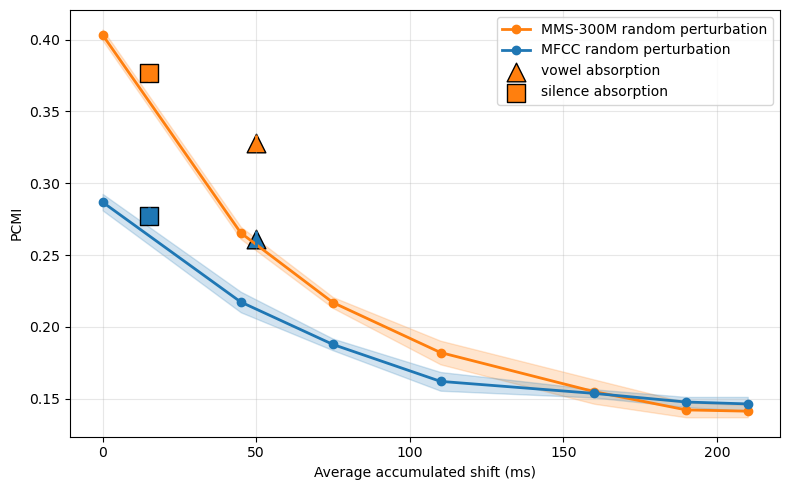

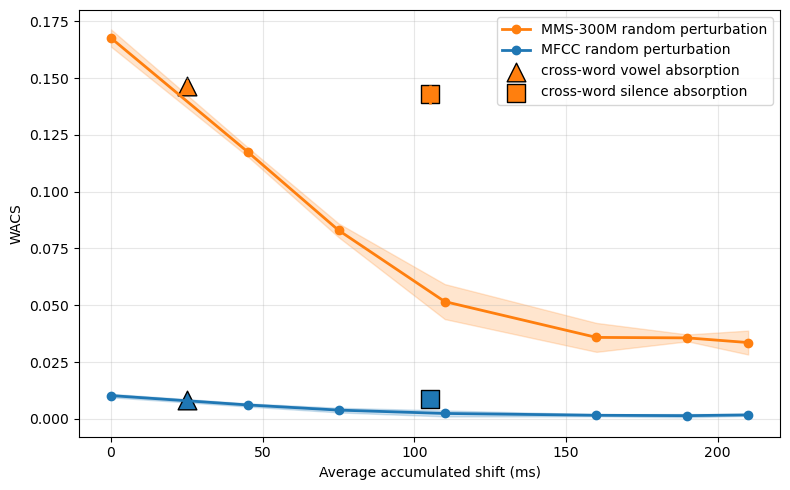

In [2]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# LOAD
# ---------------------------------------------------------
with open("results/perturbation.json") as fp:
    results = json.load(fp)

os.makedirs(
    "results/plots",
    exist_ok=True
)

# ---------------------------------------------------------
# MODELS
# ---------------------------------------------------------
MODELS = [
    "facebook/mms-300m",
    "mfcc",
]

MODEL_NAMES = {
    "facebook/mms-300m":"MMS-300M",
    "mfcc":"MFCC",
}

MODEL_COLORS = {
    "facebook/mms-300m":"tab:orange",
    "mfcc":"tab:blue",
}

# ---------------------------------------------------------
# AAS MAP
# ---------------------------------------------------------
aas_map = {
    "tg":0,
    "tg_50":45,
    "tg_100":75,
    "tg_200":110,
    "tg_500":160,
    "tg_1000":190,
    "tg_2000":210,

    # systematic
    "tg_VC":50,
    "tg_VC_boundary":25,
    "tg_SIL":15,
    "tg_SIL_boundary":105,
}

# ---------------------------------------------------------
# LABELS
# ---------------------------------------------------------
special_names = {
    "tg_VC":"vowel absorption",
    "tg_VC_boundary":"cross-word vowel absorption",
    "tg_SIL":"silence absorption",
    "tg_SIL_boundary":"cross-word silence absorption",
}

line_keys = [
    "tg",
    "tg_50",
    "tg_100",
    "tg_200",
    "tg_500",
    "tg_1000",
    "tg_2000",
]

special_keys = [
    "tg_VC",
    "tg_VC_boundary",
    "tg_SIL",
    "tg_SIL_boundary",
]

# ---------------------------------------------------------
# MARKERS
# ---------------------------------------------------------
special_markers = {
    "tg_VC":"^",
    "tg_VC_boundary":"^",

    "tg_SIL":"s",
    "tg_SIL_boundary":"s",
}

# ---------------------------------------------------------
# EXTRACT
# ---------------------------------------------------------
def get_metric_stats(
    model_name,
    metric_name
):

    xs = []
    means = []
    stds = []

    for k in line_keys:

        vals = [
            r[metric_name]["nmi"]
            if metric_name == "nmi"
            else r[metric_name]["wacs"]
            for r in results[model_name][k]
        ]

        xs.append(aas_map[k])
        means.append(np.mean(vals))
        stds.append(np.std(vals))

    return (
        np.array(xs),
        np.array(means),
        np.array(stds)
    )

# ---------------------------------------------------------
# PLOT
# ---------------------------------------------------------
def plot_metric(
    metric_name,
    ylabel
):

    plt.figure(figsize=(8,5))

    # -----------------------------------------------------
    # MAIN CURVES
    # -----------------------------------------------------
    for model_name in MODELS:

        xs, means, stds = get_metric_stats(
            model_name,
            metric_name
        )

        order = np.argsort(xs)

        xs = xs[order]
        means = means[order]
        stds = stds[order]

        color = MODEL_COLORS[model_name]

        plt.plot(
            xs,
            means,
            marker="o",
            linewidth=2,
            color=color,
            label=f"{MODEL_NAMES[model_name]} random perturbation"
        )

        plt.fill_between(
            xs,
            means-stds,
            means+stds,
            alpha=0.2,
            color=color
        )

    # -----------------------------------------------------
    # SYSTEMATIC PERTURBATIONS
    # -----------------------------------------------------
    added_labels = set()

    for model_name in MODELS:

        color = MODEL_COLORS[model_name]

        for k in special_keys:

            if metric_name == "nmi" and "boundary" in k:
                continue

            if metric_name == "wacs" and "boundary" not in k:
                continue

            vals = [
                r[metric_name]["nmi"]
                if metric_name == "nmi"
                else r[metric_name]["wacs"]
                for r in results[model_name][k]
            ]

            mean = np.mean(vals)
            std = np.std(vals)

            x = aas_map[k]

            label = special_names[k]

            if label in added_labels:
                label = None
            else:
                added_labels.add(label)

            plt.scatter(
                [x],
                [mean],
                marker=special_markers[k],
                s=180,
                color=color,
                label=label,
                edgecolors="black"
            )

            plt.vlines(
                x,
                mean-std,
                mean+std,
                linewidth=2,
                color=color
            )

    # -----------------------------------------------------
    # COSMETICS
    # -----------------------------------------------------
    plt.xlabel(
        "Average accumulated shift (ms)"
    )

    plt.ylabel(ylabel)

    plt.grid(
        True,
        alpha=0.3
    )

    plt.legend()

    plt.tight_layout()

    plt.savefig(
        f"results/plots/perturb_{ylabel}.png",
        dpi=200
    )

    plt.show()

# ---------------------------------------------------------
# RUN
# ---------------------------------------------------------
plot_metric(
    "nmi",
    "PCMI"
)

plot_metric(
    "wacs",
    "WACS"
)

## Layer tuning

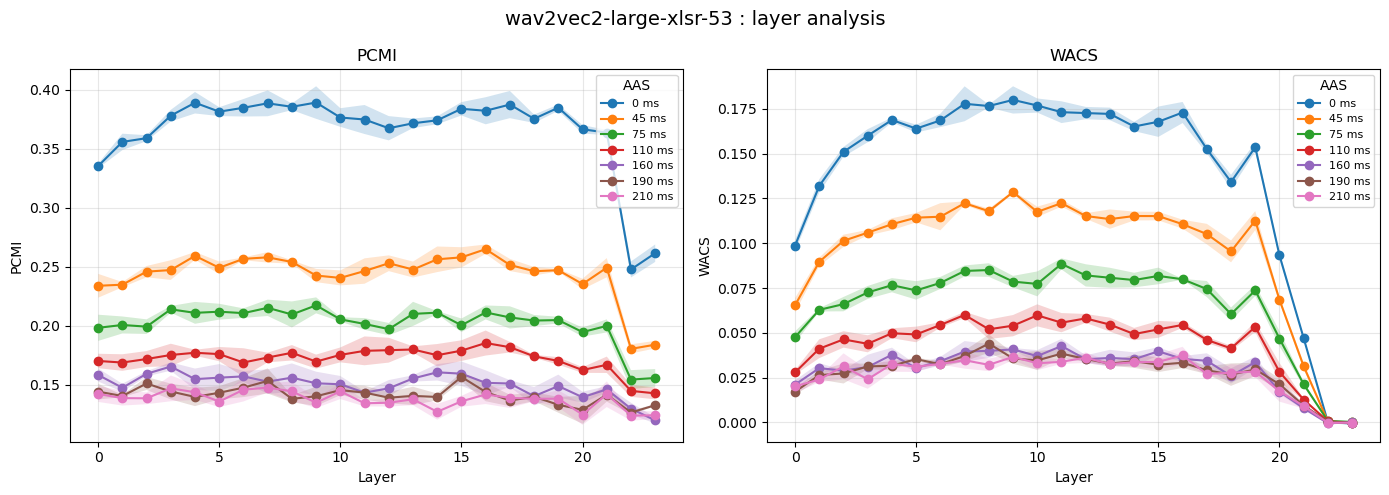

saved -> results/plots/wav2vec2-large-xlsr-53_layers.png


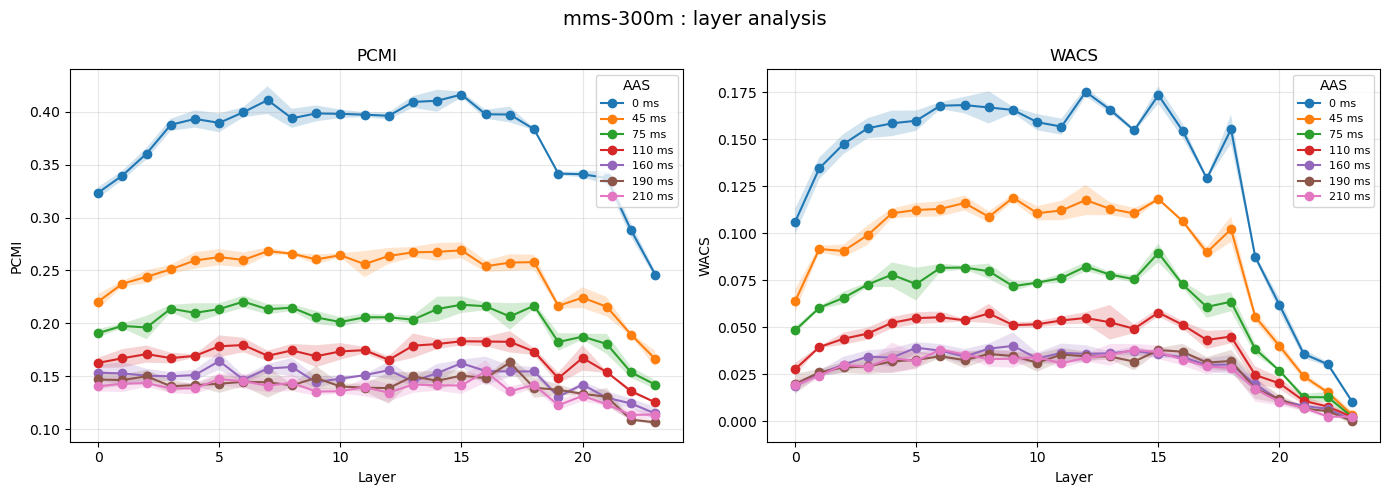

saved -> results/plots/mms-300m_layers.png


In [56]:
import os,json
import numpy as np
import matplotlib.pyplot as plt

with open("results/layer_tuning.json") as fp:
    results=json.load(fp)

os.makedirs(
    "results/plots",
    exist_ok=True
)

tg_order=[
    "tg",
    "tg_50",
    "tg_100",
    "tg_200",
    "tg_500",
    "tg_1000",
    "tg_2000"
]

aas_map={
    "tg":0,
    "tg_50":45,
    "tg_100":75,
    "tg_200":110,
    "tg_500":160,
    "tg_1000":190,
    "tg_2000":210,
}

for model,model_data in results.items():

    layers=sorted([
        int(k.split("_")[-1])
        for k in model_data.keys()
    ])

    fig,axes=plt.subplots(
        1,
        2,
        figsize=(14,5),
        sharex=True
    )

    # -------------------------------------------------
    # PCMI
    # -------------------------------------------------
    ax=axes[0]

    for tg_name in tg_order:

        means=[]
        stds=[]

        for layer in layers:

            runs=model_data[
                f"layer_{layer}"
            ][tg_name]

            vals=[
                r["nmi"]["nmi"]
                for r in runs
                if r["nmi"] is not None
            ]

            if len(vals)>0:

                means.append(
                    np.mean(vals)
                )

                stds.append(
                    np.std(vals)
                )

            else:

                means.append(np.nan)
                stds.append(np.nan)

        means=np.array(means)
        stds=np.array(stds)

        label=f"{aas_map[tg_name]} ms"

        ax.plot(
            layers,
            means,
            marker="o",
            label=label
        )

        ax.fill_between(
            layers,
            means-stds,
            means+stds,
            alpha=0.2
        )

    ax.set_xlabel("Layer")
    ax.set_ylabel("PCMI")
    ax.set_title("PCMI")
    ax.grid(True,alpha=0.3)
    ax.legend(
        title="AAS",
        fontsize=8
    )

    # -------------------------------------------------
    # WACS
    # -------------------------------------------------
    ax=axes[1]

    for tg_name in tg_order:

        means=[]
        stds=[]

        for layer in layers:

            runs=model_data[
                f"layer_{layer}"
            ][tg_name]

            vals=[
                r["wacs"]["wacs"]
                for r in runs
                if r["wacs"] is not None
            ]

            if len(vals)>0:

                means.append(
                    np.mean(vals)
                )

                stds.append(
                    np.std(vals)
                )

            else:

                means.append(np.nan)
                stds.append(np.nan)

        means=np.array(means)
        stds=np.array(stds)

        label=f"{aas_map[tg_name]} ms"

        ax.plot(
            layers,
            means,
            marker="o",
            label=label
        )

        ax.fill_between(
            layers,
            means-stds,
            means+stds,
            alpha=0.2
        )

    ax.set_xlabel("Layer")
    ax.set_ylabel("WACS")
    ax.set_title("WACS")
    ax.grid(True,alpha=0.3)
    ax.legend(
        title="AAS",
        fontsize=8
    )

    fig.suptitle(
        f"{model.split('/')[-1]} : layer analysis",
        fontsize=14
    )

    plt.tight_layout()

    out_path=os.path.join(
        "results/plots",
        f"{model.split('/')[-1]}_layers.png"
    )

    plt.savefig(
        out_path,
        dpi=200,
        bbox_inches="tight"
    )
    plt.show()
    plt.close()

    print(
        "saved ->",
        out_path
    )

## K-means tuning

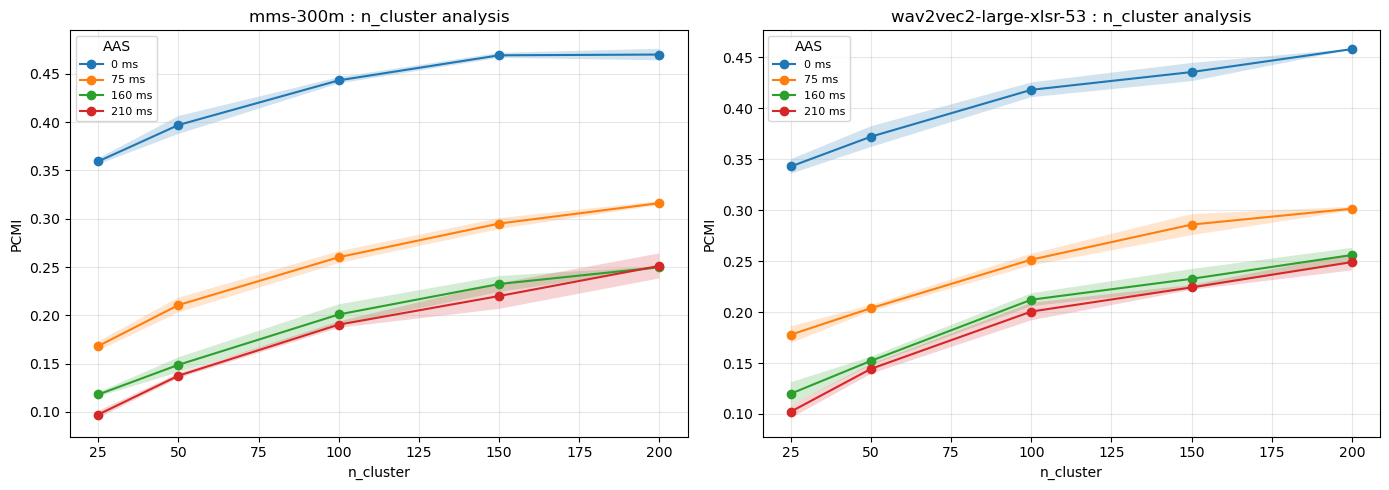

saved -> results/plots/n_cluster_tuning.png
PCMI range: [array([0.2621808 , 0.25958058, 0.25294748, 0.24926011, 0.21883391]), array([0.24059405, 0.22783491, 0.21756131, 0.21129928, 0.20898234])]


In [55]:
import os,json
import numpy as np
import matplotlib.pyplot as plt

with open("results/kmeans_tuning.json") as fp:
    results=json.load(fp)

os.makedirs(
    "results/plots",
    exist_ok=True
)

tg_order=[
    "tg",
#    "tg_50",
    "tg_100",
#    "tg_200",
    "tg_500",
#    "tg_1000",
    "tg_2000"
]

aas_map={
    "tg":0,
#    "tg_50":45,
    "tg_100":75,
#    "tg_200":110,
    "tg_500":160,
#    "tg_1000":190,
    "tg_2000":210,
}

layers=sorted([
    int(k.split("_")[-1])
    for k in model_data.keys()
])

fig,axes=plt.subplots(
    1,
    2,
    figsize=(14,5),
    sharex=True
)

i = 0
diff_pcmi = []
for model,model_data in results.items():
    ax=axes[i]
    i += 1
    for tg_name in tg_order:

        means=[]
        stds=[]

        for layer in layers:

            runs=model_data[
                f"n_clusters_{layer}"
            ][tg_name]

            vals=[
                r["nmi"]["nmi"]
                for r in runs
                if r["nmi"] is not None
            ]

            if len(vals)>0:

                means.append(
                    np.mean(vals)
                )

                stds.append(
                    np.std(vals)
                )

            else:

                means.append(np.nan)
                stds.append(np.nan)

        means=np.array(means)
        stds=np.array(stds)
        if tg_name == 'tg':
            diff_pcmi.append(means)
        elif '2000' in tg_name:
            diff_pcmi[-1] -= means

        label=f"{aas_map[tg_name]} ms"

        ax.plot(
            layers,
            means,
            marker="o",
            label=label
        )

        ax.fill_between(
            layers,
            means-stds,
            means+stds,
            alpha=0.2
        )
        

    ax.set_xlabel(f"n_cluster")
    ax.set_ylabel("PCMI")
    ax.set_title(f"{model.split('/')[-1]} : n_cluster analysis")
    ax.grid(True,alpha=0.3)
    ax.legend(
        title="AAS",
        fontsize=8
    )

plt.tight_layout()

out_path=os.path.join(
    "results/plots",
    f"n_cluster_tuning.png"
)

plt.savefig(
    out_path,
    dpi=200,
    bbox_inches="tight"
)
plt.show()
plt.close()

print(
    "saved ->",
    out_path
)
print("PCMI range:", diff_pcmi)

## Multilingual Evalution

facebook/mms-300m random PCMI 0.09071798316356806 0.016586105809594673
facebook/mms-300m mfa PCMI 0.24659800533529191 0.10510582498391513
facebook/mms-300m mms-300m-ipa PCMI 0.23893716916753688 0.02779243614324194
facebook/mms-300m w2v2-lv-60-espeak-ipa PCMI 0.23709357018411978 0.025185891028626613
facebook/wav2vec2-large-xlsr-53 random PCMI 0.09327523888036626 0.015877206495839385
facebook/wav2vec2-large-xlsr-53 mfa PCMI 0.23102839461806413 0.09492607498387781
facebook/wav2vec2-large-xlsr-53 mms-300m-ipa PCMI 0.22622472733214855 0.025627482269796685
facebook/wav2vec2-large-xlsr-53 w2v2-lv-60-espeak-ipa PCMI 0.22493331753723242 0.023415984632047436
facebook/mms-300m random WACS 0.022370569587600808 0.014221026436246701
facebook/mms-300m mfa WACS 0.143394157643965 0.07722348073388516
facebook/mms-300m mms-300m-ipa WACS 0.19495534541612158 0.024974148380713178
facebook/mms-300m w2v2-lv-60-espeak-ipa WACS 0.19309601151490025 0.025858090099243874
facebook/mms-300m qwen3-FA WACS 0.205080456

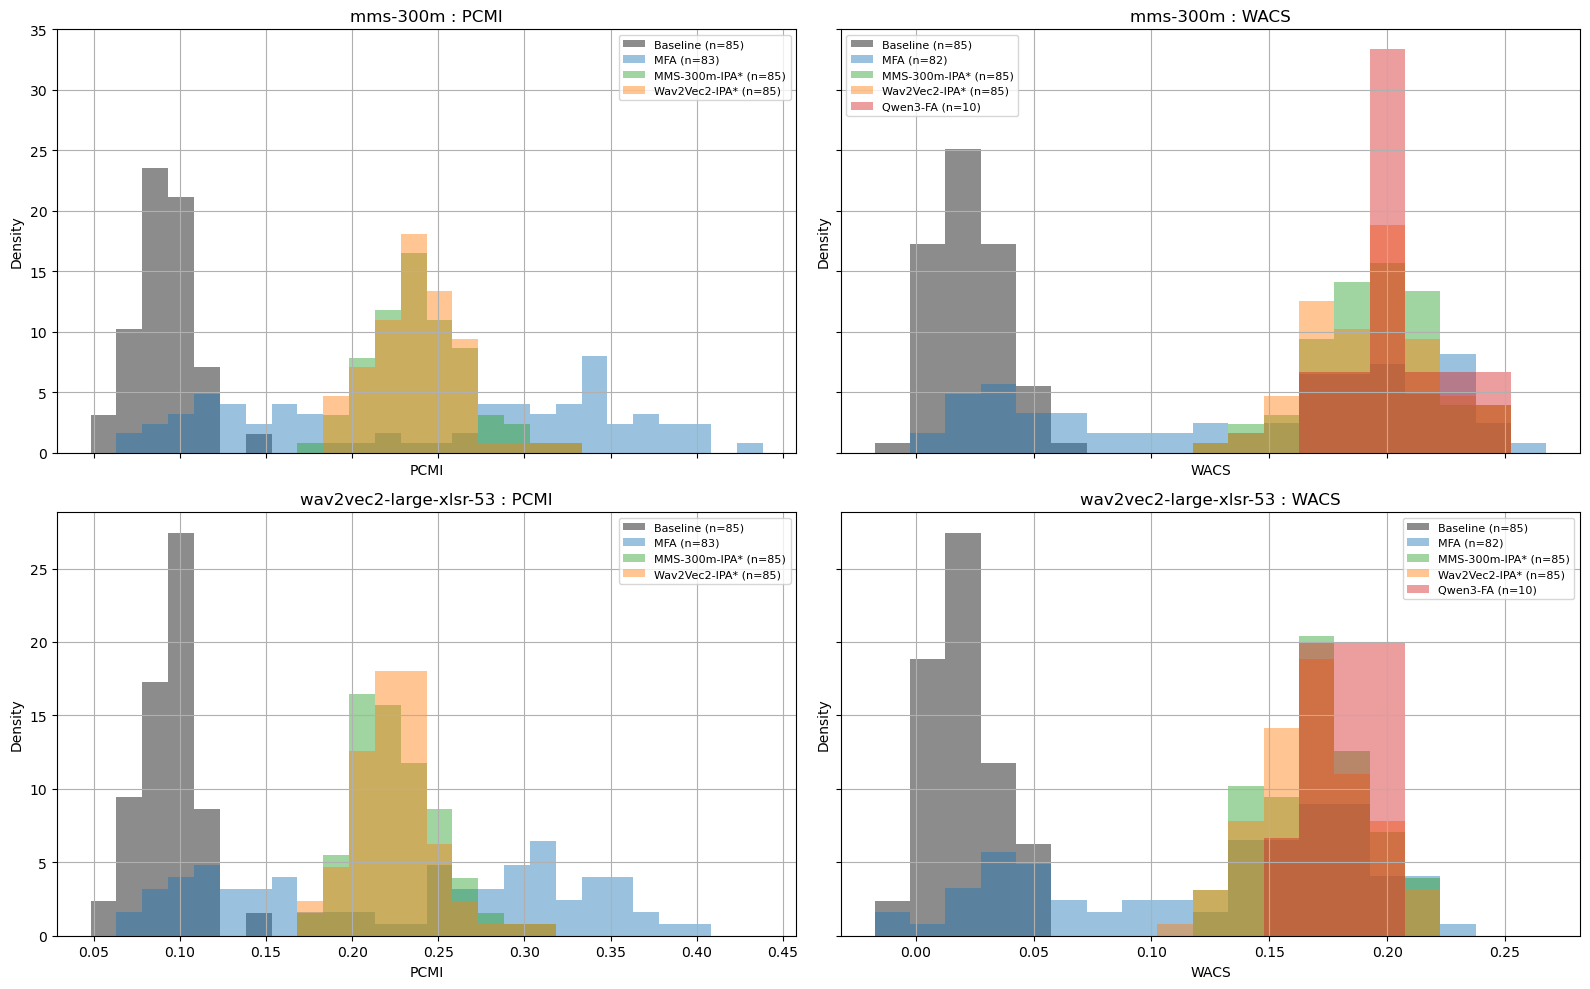

In [43]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# CONFIG
# ---------------------------------------------------------
ALIGN_MODELS=[
    "random",
    "mfa",
    "mms-300m-ipa",
    "w2v2-lv-60-espeak-ipa",
    "qwen3-FA",
]

DISPLAY_NAMES={
    "random":"Baseline",
    "mfa":"MFA",
    "mms-300m-ipa":"MMS-300m-IPA*",
    "w2v2-lv-60-espeak-ipa":"Wav2Vec2-IPA*",
    "qwen3-FA":"Qwen3-FA",
}

EMB_MODELS=[
    "facebook/mms-300m",
    "facebook/wav2vec2-large-xlsr-53",
]

COLORS={
    "random":"black",
    "mfa":"tab:blue",
    "mms-300m-ipa":"tab:green",
    "w2v2-lv-60-espeak-ipa":"tab:orange",
    "qwen3-FA":"tab:red",
}

BIN_WIDTH=0.015

# ---------------------------------------------------------
# LOAD
# ---------------------------------------------------------
all_results={}

for align_model in ALIGN_MODELS:

    path=os.path.join(
        "results",
        align_model,
        "alignment_results.json"
    )

    if not os.path.exists(path):
        continue

    with open(path) as fp:
        all_results[align_model]=json.load(fp)

# ---------------------------------------------------------
# COLLECT VALUES
# ---------------------------------------------------------
metrics={
    "nmi":{},
    "wacs":{},
}

for metric in ["nmi","wacs"]:

    for emb_model in EMB_MODELS:

        metrics[metric][emb_model]={}

        for align_model in ALIGN_MODELS:

            vals=[]

            if align_model not in all_results:
                continue

            for lang,lang_data in all_results[align_model].items():

                if emb_model not in lang_data:
                    continue

                x=lang_data[emb_model]

                if x is None or x[metric] is None:
                    continue

                vals.append(
                    x[metric][metric]
                )

            metrics[metric][emb_model][align_model]=vals

# ---------------------------------------------------------
# GLOBAL BINS
# ---------------------------------------------------------
all_nmi=[]
all_wacs=[]

for emb_model in EMB_MODELS:

    for align_model in ALIGN_MODELS:

        all_nmi.extend(
            metrics["nmi"][emb_model].get(align_model,[])
        )

        all_wacs.extend(
            metrics["wacs"][emb_model].get(align_model,[])
        )

nmi_bins=np.arange(
    min(all_nmi),
    max(all_nmi)+BIN_WIDTH,
    BIN_WIDTH
)

wacs_bins=np.arange(
    min(all_wacs),
    max(all_wacs)+BIN_WIDTH,
    BIN_WIDTH
)

# ---------------------------------------------------------
# PLOT
# ---------------------------------------------------------
fig,axes=plt.subplots(
    2,
    2,
    figsize=(16,10),
    sharex="col",
    sharey="row"
)

# =========================================================
# PCMI
# =========================================================
for row,emb_model in enumerate(EMB_MODELS):

    ax=axes[row,0]

    for align_model in ALIGN_MODELS:

        vals=metrics["nmi"][emb_model].get(
            align_model,
            []
        )

        if len(vals)==0:
            continue

        ax.hist(
            vals,
            bins=nmi_bins,
            alpha=0.45,
            density=True,
            color=COLORS[align_model],
            label=f"{DISPLAY_NAMES[align_model]} (n={len(vals)})"
        )

        print(
            emb_model,
            align_model,
            "PCMI",
            np.mean(vals),
            np.std(vals)
        )

    ax.set_title(
        f"{emb_model.split('/')[-1]} : PCMI"
    )

    ax.set_xlabel("PCMI")
    ax.set_ylabel("Density")
    ax.grid(True)
    ax.legend(fontsize=8)

# =========================================================
# WACS
# =========================================================
for row,emb_model in enumerate(EMB_MODELS):

    ax=axes[row,1]

    for align_model in ALIGN_MODELS:

        vals=metrics["wacs"][emb_model].get(
            align_model,
            []
        )

        if len(vals)==0:
            continue

        ax.hist(
            vals,
            bins=wacs_bins,
            alpha=0.45,
            density=True,
            color=COLORS[align_model],
            label=f"{DISPLAY_NAMES[align_model]} (n={len(vals)})"
        )

        print(
            emb_model,
            align_model,
            "WACS",
            np.mean(vals),
            np.std(vals)
        )

    ax.set_title(
        f"{emb_model.split('/')[-1]} : WACS"
    )

    ax.set_xlabel("WACS")
    ax.set_ylabel("Density")
    ax.grid(True)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("results/plots/multilingual.png", dpi=200)
plt.show()

facebook/mms-300m random_doreco PCMI 0.10020650537615043 0.033764948540843887
facebook/mms-300m mms-300m-ipa-doreco PCMI 0.20157109319087377 0.03224093801258252
facebook/mms-300m mms-300m-ipa-doreco-SIL PCMI 0.2027911029901738 0.032200850882402744
facebook/mms-300m gold_doreco PCMI 0.3343825384837782 0.03923578523070079
facebook/wav2vec2-large-xlsr-53 random_doreco PCMI 0.10026668969047801 0.032819695340586034
facebook/wav2vec2-large-xlsr-53 mms-300m-ipa-doreco PCMI 0.19373748909523386 0.02836418411397437
facebook/wav2vec2-large-xlsr-53 mms-300m-ipa-doreco-SIL PCMI 0.1958617819391219 0.030350486934087855
facebook/wav2vec2-large-xlsr-53 gold_doreco PCMI 0.3219912309563618 0.03675428896912388
facebook/mms-300m random_doreco WACS 0.037505447439531006 0.015942712389653932
facebook/mms-300m mms-300m-ipa-doreco WACS 0.11214872547350893 0.023728250548898648
facebook/mms-300m mms-300m-ipa-doreco-SIL WACS 0.11404553212751453 0.025843286406224828
facebook/mms-300m gold_doreco WACS 0.131236225110

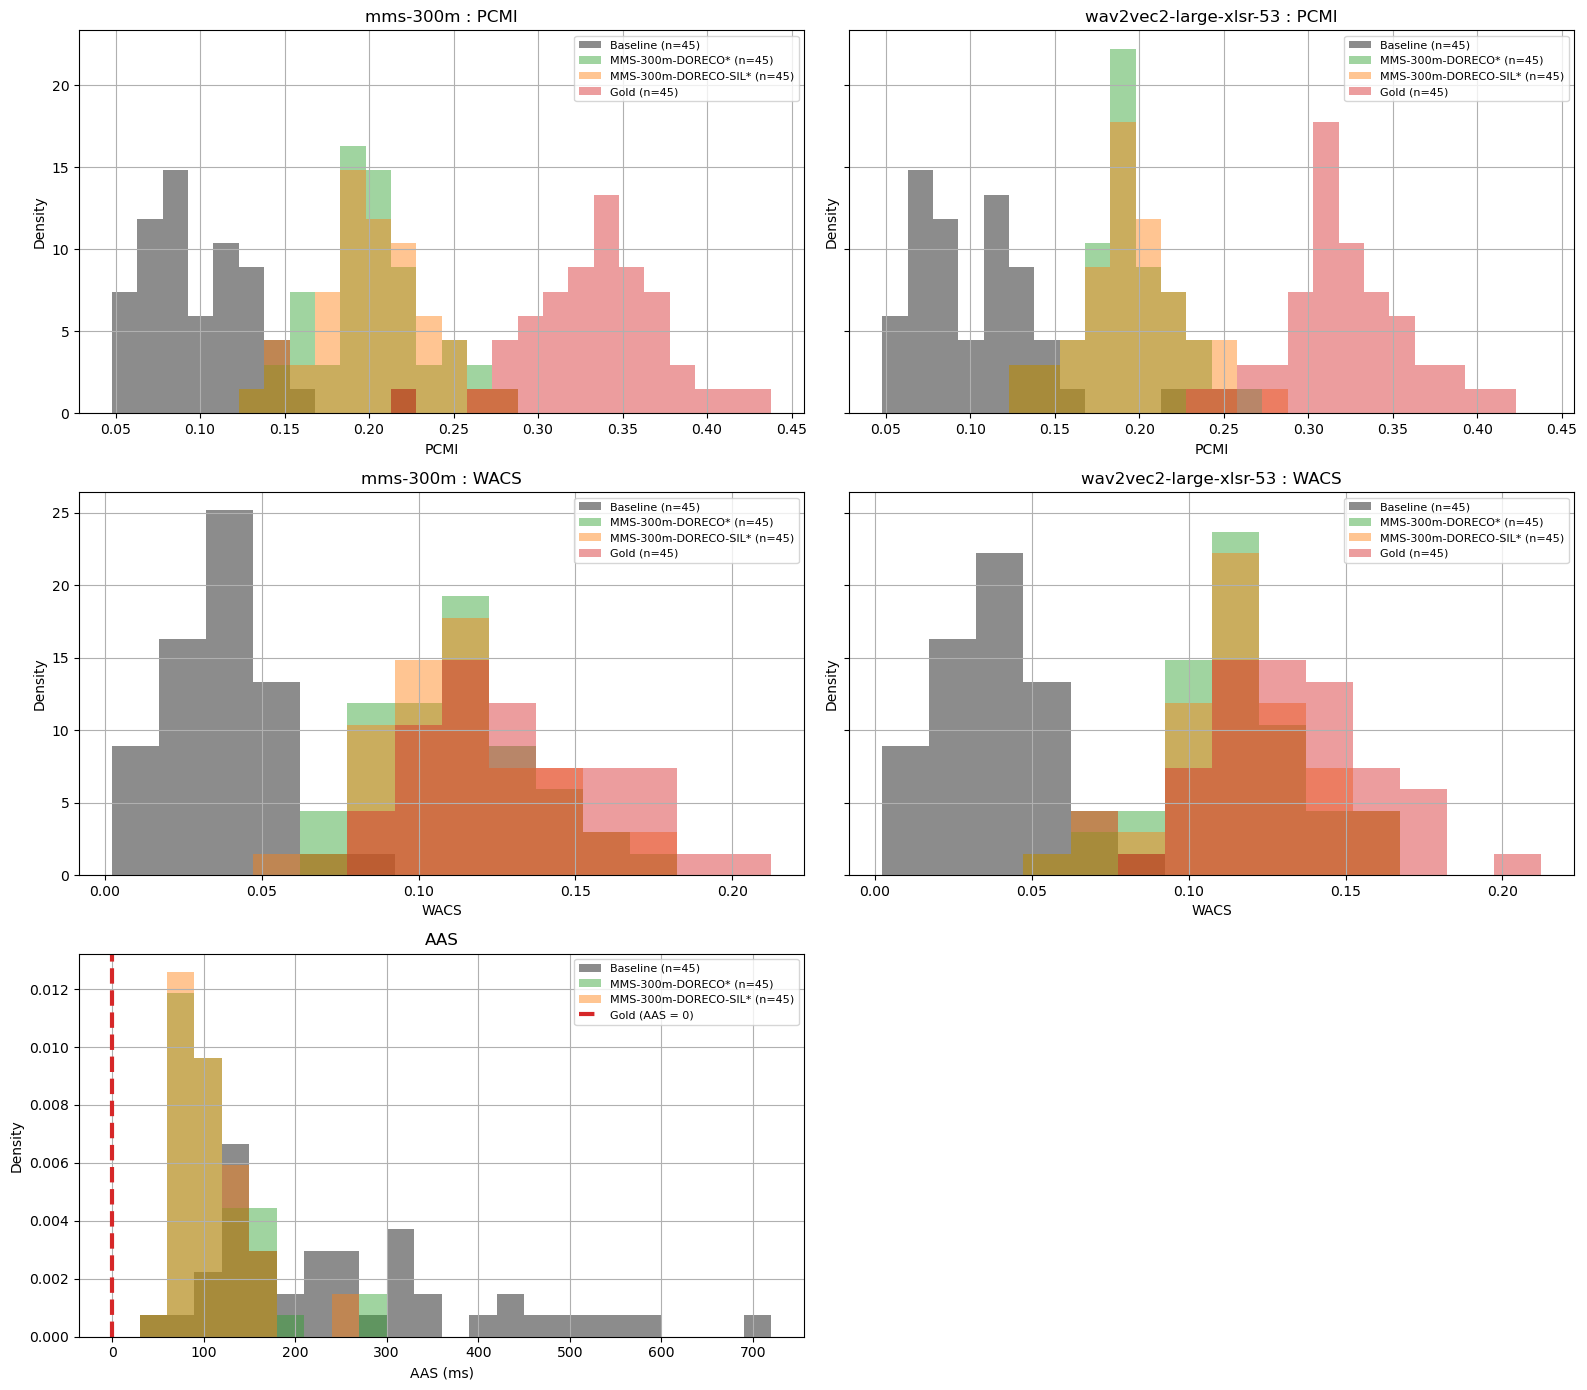

In [51]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# CONFIG
# ---------------------------------------------------------
ALIGN_MODELS = [
    "random_doreco",
    "mms-300m-ipa-doreco",
    "mms-300m-ipa-doreco-SIL",
    "gold_doreco",
]

DISPLAY_NAMES = {
    "random_doreco": "Baseline",
    "mms-300m-ipa-doreco": "MMS-300m-DORECO*",
    "mms-300m-ipa-doreco-SIL": "MMS-300m-DORECO-SIL*",
    "gold_doreco": "Gold",
}

EMB_MODELS = [
    "facebook/mms-300m",
    "facebook/wav2vec2-large-xlsr-53",
]

COLORS = {
    "random_doreco": "black",
    "mms-300m-ipa-doreco": "tab:green",
    "mms-300m-ipa-doreco-SIL": "tab:orange",
    "gold_doreco": "tab:red",
}

BIN_WIDTH_NMI = 0.015
BIN_WIDTH_WACS = 0.015
BIN_WIDTH_AAS = 30.0  # ms

# ---------------------------------------------------------
# LOAD
# ---------------------------------------------------------
all_results = {}

for align_model in ALIGN_MODELS:

    path = os.path.join(
        "results",
        align_model,
        "alignment_results.json"
    )

    if not os.path.exists(path):
        continue

    with open(path) as fp:
        all_results[align_model] = json.load(fp)

# ---------------------------------------------------------
# COLLECT VALUES
# ---------------------------------------------------------
metrics = {
    "nmi": {},
    "wacs": {},
    "aas": {},
}

for metric in ["nmi", "wacs", "aas"]:

    for emb_model in EMB_MODELS:

        metrics[metric][emb_model] = {}

        for align_model in ALIGN_MODELS:

            vals = []

            if align_model not in all_results:
                continue

            for lang, lang_data in all_results[align_model].items():

                if emb_model not in lang_data:
                    continue

                x = lang_data[emb_model]

                if x is None:
                    continue

                # -----------------------------------------
                # PCMI
                # -----------------------------------------
                if metric == "nmi":

                    if x.get("nmi") is None:
                        continue

                    vals.append(
                        x["nmi"]["nmi"]
                    )

                # -----------------------------------------
                # WACS
                # -----------------------------------------
                elif metric == "wacs":

                    if x.get("wacs") is None:
                        continue

                    vals.append(
                        x["wacs"]["wacs"]
                    )

                # -----------------------------------------
                # AAS
                # -----------------------------------------
                else:

                    if x.get("aas") is None:
                        continue

                    aas = max(
                        x["aas"].get(
                            "word_aas_ms",
                            np.nan
                        ),
                        x["aas"].get(
                            "phone_aas_ms",
                            np.nan
                        )
                    )

                    if np.isnan(aas):
                        continue

                    vals.append(aas)

            metrics[metric][emb_model][align_model] = vals

# ---------------------------------------------------------
# GLOBAL BINS
# ---------------------------------------------------------
all_nmi = []
all_wacs = []
all_aas = []

for emb_model in EMB_MODELS:

    for align_model in ALIGN_MODELS:

        all_nmi.extend(
            metrics["nmi"][emb_model].get(
                align_model,
                []
            )
        )

        all_wacs.extend(
            metrics["wacs"][emb_model].get(
                align_model,
                []
            )
        )

        if align_model != "gold_doreco":

            all_aas.extend(
                metrics["aas"][emb_model].get(
                    align_model,
                    []
                )
            )

nmi_bins = np.arange(
    min(all_nmi),
    max(all_nmi) + BIN_WIDTH_NMI,
    BIN_WIDTH_NMI
)

wacs_bins = np.arange(
    min(all_wacs),
    max(all_wacs) + BIN_WIDTH_WACS,
    BIN_WIDTH_WACS
)

aas_bins = np.arange(
    0,
    max(all_aas) + BIN_WIDTH_AAS,
    BIN_WIDTH_AAS
)

# ---------------------------------------------------------
# PLOT
# ---------------------------------------------------------
fig, axes = plt.subplots(
    3,
    2,
    figsize=(16, 14),
    sharey="row"
)

# =========================================================
# PCMI
# =========================================================
for col, emb_model in enumerate(EMB_MODELS):

    ax = axes[0, col]

    for align_model in ALIGN_MODELS:

        vals = metrics["nmi"][emb_model].get(
            align_model,
            []
        )

        if len(vals) == 0:
            continue

        ax.hist(
            vals,
            bins=nmi_bins,
            alpha=0.45,
            density=True,
            color=COLORS[align_model],
            label=f"{DISPLAY_NAMES[align_model]} (n={len(vals)})"
        )

        print(
            emb_model,
            align_model,
            "PCMI",
            np.mean(vals),
            np.std(vals)
        )

    ax.set_title(
        f"{emb_model.split('/')[-1]} : PCMI"
    )

    ax.set_xlabel("PCMI")
    ax.set_ylabel("Density")
    ax.grid(True)
    ax.legend(fontsize=8)

# =========================================================
# WACS
# =========================================================
for col, emb_model in enumerate(EMB_MODELS):

    ax = axes[1, col]

    for align_model in ALIGN_MODELS:

        vals = metrics["wacs"][emb_model].get(
            align_model,
            []
        )

        if len(vals) == 0:
            continue

        ax.hist(
            vals,
            bins=wacs_bins,
            alpha=0.45,
            density=True,
            color=COLORS[align_model],
            label=f"{DISPLAY_NAMES[align_model]} (n={len(vals)})"
        )

        print(
            emb_model,
            align_model,
            "WACS",
            np.mean(vals),
            np.std(vals)
        )

    ax.set_title(
        f"{emb_model.split('/')[-1]} : WACS"
    )

    ax.set_xlabel("WACS")
    ax.set_ylabel("Density")
    ax.grid(True)
    ax.legend(fontsize=8)

# =========================================================
# AAS
# =========================================================
for col, emb_model in enumerate(EMB_MODELS):

    ax = axes[2, col]

    for align_model in ALIGN_MODELS:

        vals = metrics["aas"][emb_model].get(
            align_model,
            []
        )

        if len(vals) == 0:
            continue

        # -------------------------------------
        # gold shown as vertical line
        # -------------------------------------
        if align_model == "gold_doreco":

            ax.axvline(
                0,
                color=COLORS[align_model],
                linewidth=3,
                linestyle="--",
                label="Gold (AAS = 0)"
            )

            continue

        ax.hist(
            vals,
            bins=aas_bins,
            alpha=0.45,
            density=True,
            color=COLORS[align_model],
            label=f"{DISPLAY_NAMES[align_model]} (n={len(vals)})"
        )

        print(
            emb_model,
            align_model,
            "AAS",
            np.mean(vals),
            np.std(vals)
        )

    ax.set_title(
        f"AAS"
    )

    ax.set_xlabel("AAS (ms)")
    ax.set_ylabel("Density")
    ax.grid(True)
    ax.legend(fontsize=8)
    break

# ---------------------------------------------------------
# Disable unused panel
# ---------------------------------------------------------
axes[2, 1].axis("off")

plt.tight_layout()
plt.savefig(
    "results/plots/multilingual_doreco.png",
    dpi=200
)
plt.show()

## DoReCo correlations

In [49]:
import os
import json
import numpy as np
from scipy.stats import pearsonr

# ---------------------------------------------------------
# CONFIG
# ---------------------------------------------------------
ALIGN_MODELS = [
    "gold_doreco",
    "random_doreco",
    "mms-300m-ipa-doreco",
    "mms-300m-ipa-doreco-SIL",
]

EMB_MODELS = [
    "facebook/mms-300m",
    "facebook/wav2vec2-large-xlsr-53",
]

EMB_NAMES = {
    "facebook/mms-300m": "MMS",
    "facebook/wav2vec2-large-xlsr-53": "XLSR",
}

OUT_PATH = "results/tables/doreco_aas_correlations.tex"

# ---------------------------------------------------------
# HELPERS
# ---------------------------------------------------------
def corr(pairs):
    if len(pairs) < 3:
        return np.nan, np.nan

    x = np.array([p[0] for p in pairs], dtype=float)
    y = np.array([p[1] for p in pairs], dtype=float)

    mask = np.isfinite(x) & np.isfinite(y)

    x = x[mask]
    y = y[mask]

    if len(x) < 3:
        return np.nan, np.nan

    if np.std(x) == 0 or np.std(y) == 0:
        return np.nan, np.nan

    return pearsonr(x, y)


def fmt_r(x):
    if np.isnan(x):
        return "-"
    return f"{x:.4f}"


def p_to_tex(p):
    if np.isnan(p):
        return "-"

    if p < 0.001:
        return r"$<0.001^{***}$"
    elif p < 0.01:
        return rf"${p:.4f}^{{**}}$"
    elif p < 0.05:
        return rf"${p:.4f}^{{*}}$"
    else:
        return f"{p:.4f}"


# ---------------------------------------------------------
# COLLECT
# ---------------------------------------------------------
results = {}
golds = []

for emb_model in EMB_MODELS:

    pcmi_pairs = []
    wacs_pairs = []

    for align_model in ALIGN_MODELS:

        path = f"results/{align_model}/alignment_results.json"

        if not os.path.exists(path):
            continue

        with open(path) as fp:
            data = json.load(fp)

        for lang, lang_data in data.items():

            if emb_model not in lang_data:
                continue

            entry = lang_data[emb_model]

            try:
                pcmi = entry["nmi"]["nmi"]
                wacs = entry["wacs"]["wacs"]

                word_aas = entry["aas"]["word_aas_ms"]
                phone_aas = entry["aas"]["phone_aas_ms"]

            except (KeyError, TypeError):
                continue

            aas = max(word_aas, phone_aas)

            vals = [pcmi, wacs, aas]

            if "gold" in align_model:
                golds.append(vals)

            if not all(np.isfinite(v) for v in vals):
                continue

            pcmi_pairs.append((pcmi, aas))
            wacs_pairs.append((wacs, aas))

    results[emb_model] = {
        "PCMI vs AAS": corr(pcmi_pairs),
        "WACS vs AAS": corr(wacs_pairs),
        "N": len(pcmi_pairs),
    }

# ---------------------------------------------------------
# PRINT GOLD SUMMARY
# ---------------------------------------------------------
if len(golds) > 0:

    golds = np.array(golds)

    print("\nGold alignment statistics")
    print("-------------------------")
    print("Mean:", golds.mean(axis=0))
    print("Std :", golds.std(axis=0))

# ---------------------------------------------------------
# LATEX TABLE
# ---------------------------------------------------------
latex = []

latex.append(r"\begin{table}[t]")
latex.append(r"\centering")
latex.append(r"\small")
latex.append(r"\begin{tabular}{llcc}")
latex.append(r"\toprule")
latex.append(
    r"\textbf{Embedding} & "
    r"\textbf{Metric Pair} & "
    r"\textbf{$r$} & "
    r"\textbf{$p$} \\"
)
latex.append(r"\midrule")

for emb_model in EMB_MODELS:

    emb_name = EMB_NAMES[emb_model]

    r1, p1 = results[emb_model]["PCMI vs AAS"]
    r2, p2 = results[emb_model]["WACS vs AAS"]

    latex.append(
        rf"\multirow{{2}}{{*}}{{{emb_name}}} "
        rf"& PCMI vs AAS "
        rf"& {fmt_r(r1)} "
        rf"& {p_to_tex(p1)} \\"
    )

    latex.append(
        rf"& WACS vs AAS "
        rf"& {fmt_r(r2)} "
        rf"& {p_to_tex(p2)} \\"
    )

    if emb_model != EMB_MODELS[-1]:
        latex.append(r"\midrule")

latex.append(r"\bottomrule")
latex.append(r"\end{tabular}")

latex.append(
    r"\caption{Pearson correlation between reference-free metrics "
    r"(PCMI, WACS) and alignment quality measured by "
    r"$\mathrm{AAS}=\max(\mathrm{Word\ AAS},\mathrm{Phone\ AAS})$ "
    r"on the 45-language DoReCo evaluation set. "
    r"Lower AAS indicates better alignment quality.}"
)

latex.append(r"\label{tab:doreco_corr_aas}")
latex.append(r"\end{table}")

# ---------------------------------------------------------
# SAVE
# ---------------------------------------------------------
os.makedirs(os.path.dirname(OUT_PATH), exist_ok=True)

with open(OUT_PATH, "w") as fp:
    fp.write("\n".join(latex))

print(f"\nsaved {OUT_PATH}")

# ---------------------------------------------------------
# ALSO PRINT TO TERMINAL
# ---------------------------------------------------------
for emb_model in EMB_MODELS:

    print("\n" + "=" * 70)
    print(EMB_NAMES[emb_model])
    print("=" * 70)

    for metric in ["PCMI vs AAS", "WACS vs AAS"]:

        r, p = results[emb_model][metric]

        print(
            f"{metric:15s} "
            f"r={r:8.4f} "
            f"p={p_to_tex(p)}"
        )


Gold alignment statistics
-------------------------
Mean: [0.32818688 0.13241836 0.        ]
Std : [0.03851686 0.02618294 0.        ]

saved results/tables/doreco_aas_correlations.tex

MMS
PCMI vs AAS     r= -0.7769 p=$<0.001^{***}$
WACS vs AAS     r= -0.6257 p=$<0.001^{***}$

XLSR
PCMI vs AAS     r= -0.7761 p=$<0.001^{***}$
WACS vs AAS     r= -0.6686 p=$<0.001^{***}$


## Cluster purities

In [35]:
import os,json
import numpy as np

# ---------------------------------------------------------
# CONFIG
# ---------------------------------------------------------
ALIGN_MODELS=[
    "random",
    "mfa",
    "mms-300m-ipa",
    "w2v2-lv-60-espeak-ipa",
    "qwen3-FA",
    "random_doreco",
    "mms-300m-ipa-doreco",
    "mms-300m-ipa-doreco-SIL"
]

EMB_MODELS=[
    "facebook/mms-300m",
    "facebook/wav2vec2-large-xlsr-53",
]

DISPLAY_NAMES={
    "random":"Baseline (FLEURS)",
    "mfa":"MFA (FLEURS)",
    "mms-300m-ipa":"MMS-300M-IPA* (FLEURS)",
    "w2v2-lv-60-espeak-ipa":"Wav2Vec2-IPA* (FLEURS)",
    "qwen3-FA":"Qwen3-FA (FLEURS)",
    "random_doreco": "Baseline (DoReCo)",
    "mms-300m-ipa-doreco": "MMS-300M-DoReCo*",
    "mms-300m-ipa-doreco-SIL": "MMS-300M-DoReCo-SIL*",
}

FIELD_DISPLAY={
    "nmi.nmi":"PCMI",
    "nmi.mean_cluster_purity":"Mean cluster purity",
    "nmi.std_cluster_purity":"Std cluster purity",
    "nmi.cluster_entropy":"Cluster entropy",
    "nmi.cluster_entropy_norm":"Norm. cluster entropy",
    "nmi.label_entropy":"Label entropy",
    "nmi.label_entropy_norm":"Norm. label entropy",
    "nmi.clusters_used":"Clusters used",
    "nmi.labels":"Labels",
    "nmi.frames":"Frames",
    "wacs.wacs":"WACS",
    "wacs.positive":"Positive DTW",
    "wacs.negative":"Negative DTW",
    "wacs.positive_std":"Positive std",
    "wacs.negative_std":"Negative std",
    "wacs.positive_min":"Positive min",
    "wacs.negative_min":"Negative min",
    "wacs.positive_max":"Positive max",
    "wacs.negative_max":"Negative max",
    "wacs.positive_pairs":"Positive pairs",
    "wacs.negative_pairs":"Negative pairs",
    "wacs.vocab_size":"Vocabulary size",
    "wacs.cohen_d":"Cohen's d",
    "wacs.snr":"SNR",
}

FIELD_ORDER=list(FIELD_DISPLAY.keys())

# ---------------------------------------------------------
# LOAD
# ---------------------------------------------------------
all_results={}

for align_model in ALIGN_MODELS:

    path=os.path.join(
        "results",
        align_model,
        "alignment_results.json"
    )

    if not os.path.exists(path):
        continue

    with open(path) as fp:
        all_results[align_model]=json.load(fp)

# ---------------------------------------------------------
# AGGREGATE
# ---------------------------------------------------------
summary={}

for align_model,data in all_results.items():

    summary[align_model]={}

    for emb_model in EMB_MODELS:

        collected={
            field:[]
            for field in FIELD_ORDER
        }

        for lang,lang_data in data.items():

            if emb_model not in lang_data:
                continue

            vals=lang_data[emb_model]

            if vals is None:
                continue

            for field in FIELD_ORDER:

                section,key=field.split(".")

                if vals.get(section) is None:
                    continue

                v=vals[section].get(key)

                if isinstance(v,(int,float)):
                    collected[field].append(v)

        summary[align_model][emb_model]={}

        for field,xs in collected.items():

            if len(xs)==0:
                continue

            xs=np.array(xs,dtype=np.float64)

            summary[
                align_model
            ][
                emb_model
            ][
                field
            ]={
                "mean":float(np.mean(xs)),
                "std":float(np.std(xs)),
                "min":float(np.min(xs)),
                "max":float(np.max(xs)),
                "n": len(xs),
            }

# ---------------------------------------------------------
# LATEX
# ---------------------------------------------------------
latex=[]

latex.append(r"\begingroup")
latex.append(r"\scriptsize")
latex.append(r"\setlength{\tabcolsep}{2.5pt}")

latex.append(
    r"\begin{longtable}{"
    r"l"
    r"p{2.8cm}"
    r"cccc"
    r"cccc"
    r"}"
)

latex.append(
    r"\caption{Multilingual statistics across aligners and embedding models.}"
    r"\label{tab:multilingual-stats}\\"
)

# ---------------------------------------------------------
# LATEX HEADERS (BOLD)
# ---------------------------------------------------------
latex.append(r"\toprule")

latex.append(
    r"\multirow{2}{*}{\textbf{Aligner}} & "
    r"\multirow{2}{*}{\textbf{Metric}} & "
    r"\multicolumn{4}{c}{\textbf{MMS}} & "
    r"\multicolumn{4}{c}{\textbf{XLSR}} \\"
)

latex.append(
    r"\cmidrule(lr){3-6}\cmidrule(lr){7-10}"
)

latex.append(
    r"& & "
    r"\textbf{Mean} & "
    r"\textbf{Std} & "
    r"\textbf{Min} & "
    r"\textbf{Max} "
    r"& "
    r"\textbf{Mean} & "
    r"\textbf{Std} & "
    r"\textbf{Min} & "
    r"\textbf{Max} \\"
)

latex.append(r"\midrule")
latex.append(r"\endfirsthead")

latex.append(r"\toprule")

latex.append(
    r"\multirow{2}{*}{\textbf{Aligner}} & "
    r"\multirow{2}{*}{\textbf{Metric}} & "
    r"\multicolumn{4}{c}{\textbf{MMS}} & "
    r"\multicolumn{4}{c}{\textbf{XLSR}} \\"
)

latex.append(
    r"\cmidrule(lr){3-6}\cmidrule(lr){7-10}"
)

latex.append(
    r"& & "
    r"\textbf{Mean} & "
    r"\textbf{Std} & "
    r"\textbf{Min} & "
    r"\textbf{Max} "
    r"& "
    r"\textbf{Mean} & "
    r"\textbf{Std} & "
    r"\textbf{Min} & "
    r"\textbf{Max} \\"
)

latex.append(r"\midrule")
latex.append(r"\endhead")

latex.append(r"\midrule")
latex.append(r"\endfoot")
latex.append(r"\bottomrule")
latex.append(r"\endlastfoot")

# ---------------------------------------------------------
# ROWS
# ---------------------------------------------------------
for align_model in ALIGN_MODELS:

    if align_model not in summary:
        continue

    first=True

    for field in FIELD_ORDER:
    
        row=[]
    
        if first:
    
            row.append(
                DISPLAY_NAMES[align_model]
            )
    
            first=False
    
        else:
    
            row.append("")
        row.append(FIELD_DISPLAY[field])

        for emb_model in EMB_MODELS:

            vals=summary[
                align_model
            ][
                emb_model
            ].get(field)

            if vals is None:

                row.extend([
                    "--","--","--","--"
                ])

            else:

                row.extend([
                    f"{vals['mean']:.3f}",
                    f"{vals['std']:.3f}",
                    f"{vals['min']:.3f}",
                    f"{vals['max']:.3f}",
                ])

        latex.append(
            " & ".join(row)+" \\\\"
        )

    latex.append(r"\specialrule{0.12em}{0.08em}{0.08em}")

latex.append(r"\end{longtable}")
latex.append(r"\endgroup")

# ---------------------------------------------------------
# SAVE
# ---------------------------------------------------------
os.makedirs(
    "results/tables",
    exist_ok=True
)

out_path=os.path.join(
    "results/tables",
    "multilingual_stats.tex"
)

with open(out_path,"w") as fp:

    fp.write(
        "\n".join(latex)
    )

print("saved ->",out_path)

saved -> results/tables/multilingual_stats.tex


In [62]:
# ---------------------------------------------------------
# HEADLINES TABLE
# ---------------------------------------------------------
os.makedirs("results/tables",exist_ok=True)

DISPLAY_NAMES={
    "random":"Baseline",
    "mfa":"MFA",
    "mms-300m-ipa":"MMS-300m-IPA*",
    "w2v2-lv-60-espeak-ipa":"Wav2Vec2-IPA*",
    "qwen3-FA":"Qwen3-FA",
}

EMB_DISPLAY={
    "facebook/mms-300m":"MMS",
    "facebook/wav2vec2-large-xlsr-53":"XLSR",
}

rows=[]

for emb_model in EMB_MODELS:

    for align_model in ALIGN_MODELS:

        if align_model not in summary:
            continue

        if emb_model not in summary[align_model]:
            continue

        vals=summary[align_model][emb_model]

        rows.append({
            "Embedding":
                EMB_DISPLAY[emb_model],

            "Alignment model":
                DISPLAY_NAMES.get(
                    align_model,
                    align_model
                ),

            "N_Langs":
                f"{vals['wacs.wacs']['n']}",

            "PCMI":
                (
                    f"{vals['nmi.nmi']['mean']:.2f} "
                    f"$\\pm$ "
                    f"{vals['nmi.nmi']['std']:.2f}"
                )
                if "nmi.nmi" in vals
                else "-",

            "WACS":
                (
                    f"{vals['wacs.wacs']['mean']:.2f} "
                    f"$\\pm$ "
                    f"{vals['wacs.wacs']['std']:.2f}"
                ),
        })

headline_df=pd.DataFrame(rows)

print(headline_df.to_string(index=False))

# ---------------------------------------------------------
# LATEX
# ---------------------------------------------------------
latex=[]

latex.append(r"\begin{table}[t]")
latex.append(r"\centering")
latex.append(r"\resizebox{\columnwidth}{!}{%")
latex.append(r"\begin{tabular}{llccc}")
latex.append(r"\toprule")

latex.append(
    r"\textbf{Emb.} & "
    r"\textbf{Alignment model} & "
    r"\textbf{\#Langs} & "
    r"\textbf{PCMI} $\uparrow$ & "
    r"\textbf{WACS} $\uparrow$ \\"
)

latex.append(r"\midrule")

for emb_name in ["MMS","XLSR"]:

    subdf=headline_df[
        headline_df["Embedding"]==emb_name
    ]

    first=True

    for _,row in subdf.iterrows():

        emb_col=(
            rf"\multirow{{{len(subdf)}}}{{*}}{{{emb_name}}}"
            if first else ""
        )

        first=False

        latex.append(
            f"{emb_col} & "
            f"{row['Alignment model']} & "
            f"{row['N_Langs']} & "
            f"{row['PCMI']} & "
            f"{row['WACS']} \\\\"
        )

    latex.append(r"\midrule")

latex=latex[:-1]

latex.append(r"\bottomrule")
latex.append(r"\end{tabular}")
latex.append(r"}")

latex.append(
    r"\caption{Multilingual evaluation of forced alignment using PCMI and WACS across 85 languages. Results are shown using MMS and XLSR speech representations. * trained in this work.}"
)

latex.append(r"\label{tab:headline_metrics}")
latex.append(r"\end{table}")

latex="\n".join(latex)

out_path="results/tables/headlines.tex"

with open(out_path,"w") as fp:
    fp.write(latex)

print(f"saved {out_path}")

Embedding Alignment model N_Langs            PCMI            WACS
      MMS        Baseline      85 0.09 $\pm$ 0.02 0.02 $\pm$ 0.01
      MMS             MFA      82 0.25 $\pm$ 0.11 0.14 $\pm$ 0.08
      MMS   MMS-300m-IPA*      85 0.24 $\pm$ 0.03 0.19 $\pm$ 0.02
      MMS   Wav2Vec2-IPA*      85 0.24 $\pm$ 0.03 0.19 $\pm$ 0.03
      MMS        Qwen3-FA      10               - 0.21 $\pm$ 0.02
     XLSR        Baseline      85 0.09 $\pm$ 0.02 0.02 $\pm$ 0.01
     XLSR             MFA      82 0.23 $\pm$ 0.09 0.13 $\pm$ 0.07
     XLSR   MMS-300m-IPA*      85 0.23 $\pm$ 0.03 0.17 $\pm$ 0.02
     XLSR   Wav2Vec2-IPA*      85 0.22 $\pm$ 0.02 0.17 $\pm$ 0.02
     XLSR        Qwen3-FA      10               - 0.18 $\pm$ 0.01
saved results/tables/headlines.tex


## Language Info

In [91]:
import os
import json
import pandas as pd
import numpy as np

# ---------------------------------------------------------
# CONFIG
# ---------------------------------------------------------
MODELS = [
    "mms-300m-ipa",
    "w2v2-lv-60-espeak-ipa",
]

SPLITS = [
    "train",
    "dev",
    "test",
]

OUT_DIR = "results/tables"

os.makedirs(
    OUT_DIR,
    exist_ok=True
)

# ---------------------------------------------------------
# LOAD ASR
# ---------------------------------------------------------
all_results = {}

for model in MODELS:

    path = os.path.join(
        "results",
        model,
        "asr.json"
    )

    if not os.path.exists(path):
        continue

    with open(path) as fp:
        all_results[model] = json.load(fp)

# ---------------------------------------------------------
# META
# ---------------------------------------------------------
meta = pd.read_csv(
    "lang_meta.tsv",
    sep="\t"
).fillna('-')

meta["lang"] = meta["dir"].apply(
    lambda x: os.path.basename(str(x))
)

meta["_order"] = np.arange(len(meta))

# ---------------------------------------------------------
# LANGS USED
# ---------------------------------------------------------
langs = set()

for model, data in all_results.items():
    langs.update(data.keys())

# ---------------------------------------------------------
# BUILD DF
# ---------------------------------------------------------
rows = []

for _, m in meta.iterrows():

    lang = m["lang"]

    if lang not in langs:
        continue

    row = {}

    row["name"] = m.get("name", "")
    row["division"] = m.get("division", "")
    row["iso639_1"] = m.get("iso639-1", "")
    row["iso639_3"] = m.get("iso639-3", "")
    row["family"] = m.get("family", "")
    row["subfamily"] = m.get("subfamily", "")

    # -----------------------------------------------------
    # G2P
    # -----------------------------------------------------
    if m.get("xpf") == 1:
        row["g2p"] = "xpf"

    elif pd.notna(m.get("epitran")):
        row["g2p"] = "epitran"

    else:
        row["g2p"] = "-"

    # -----------------------------------------------------
    # SPLIT SIZES
    # -----------------------------------------------------
    ipa_root = os.path.join(
        "fleurs_ipa_asr",
        lang
    )

    for split in SPLITS:

        path = os.path.join(
            ipa_root,
            f"{split}_sentences_ipa.tsv"
        )

        if os.path.exists(path):

            try:

                df_split = pd.read_csv(
                    path,
                    sep="\t"
                )

                row[split] = len(df_split)

            except:
                row[split] = "-"

        else:
            row[split] = "-"

    rows.append(row)

df = pd.DataFrame(rows)

# ---------------------------------------------------------
# SAVE CSV
# ---------------------------------------------------------
csv_path = os.path.join(
    OUT_DIR,
    "language_info.csv"
)

df.to_csv(
    csv_path,
    index=False
)

print(f"saved {csv_path}")

# ---------------------------------------------------------
# LATEX LONGTABLE
# ---------------------------------------------------------
latex = []

latex.append(r"\begingroup")
latex.append(r"\small")
latex.append(r"\setlength{\tabcolsep}{2.8pt}")
latex.append(r"\renewcommand{\arraystretch}{0.92}")

latex.append(
    r"\begin{longtable}{"
    r"lllllllllll"
    r"}"
)

latex.append(
    r"\caption{Languages used in multilingual evaluation.}"
    r"\label{tab:language_info}\\"
)

latex.append(r"\toprule")

latex.append(
    r"\textbf{Language} & "
    r"\textbf{ISO-1} & "
    r"\textbf{ISO-3} & "
    r"\textbf{Family} & "
    r"\textbf{Subfamily} & "
    r"\textbf{Division} & "
    r"\textbf{Train} & "
    r"\textbf{Dev} & "
    r"\textbf{Test} & "
    r"\textbf{G2P} \\"
)

latex.append(r"\midrule")
latex.append(r"\endfirsthead")

latex.append(r"\toprule")

latex.append(
    r"\textbf{Language} & "
    r"\textbf{ISO-1} & "
    r"\textbf{ISO-3} & "
    r"\textbf{Family} & "
    r"\textbf{Subfamily} & "
    r"\textbf{Division} & "
    r"\textbf{Train} & "
    r"\textbf{Dev} & "
    r"\textbf{Test} & "
    r"\textbf{G2P} \\"
)

latex.append(r"\midrule")
latex.append(r"\endhead")

latex.append(r"\bottomrule")
latex.append(r"\endfoot")

# ---------------------------------------------------------
# ROWS
# ---------------------------------------------------------
for _, row in df.iterrows():

    latex.append(
        f"{row['name']} & "
        f"{row['iso639_1']} & "
        f"{row['iso639_3']} & "
        f"{row['family']} & "
        f"{row['subfamily']} & "
        f"{row['division']} & "
        f"{row['train']} & "
        f"{row['dev']} & "
        f"{row['test']} & "
        f"{row['g2p']} \\\\"
    )

latex.append(r"\end{longtable}")
latex.append(r"\endgroup")

# ---------------------------------------------------------
# SAVE TEX
# ---------------------------------------------------------
tex_path = os.path.join(
    OUT_DIR,
    "language_info.tex"
)

with open(tex_path, "w") as fp:
    fp.write("\n".join(latex))

print(f"saved {tex_path}")

saved results/tables/language_info.csv
saved results/tables/language_info.tex


In [26]:
from datasets import load_dataset
import os
import pandas as pd
from tqdm.auto import tqdm 

OUT_DIR = "results/tables"
os.makedirs(OUT_DIR, exist_ok=True)

# ---------------------------------------------------------
# LOAD META
# ---------------------------------------------------------
meta = pd.read_csv(
    "lang_meta_doreco.csv"
).fillna("-")

rows = []

# ---------------------------------------------------------
# BUILD TABLE
# ---------------------------------------------------------
for _, m in tqdm(meta.iterrows()):

    glottocode = str(m["glottocode"])

    data_dir = os.path.join(
        "doreco",
        "doreco_dataset",
        glottocode
    )

    if not os.path.isdir(data_dir):
        continue

    row = {
        "name": m["name"],
        "iso639_3": m["iso-639-3"],
        "family": m["family"],
        "subfamily": m["subfamily"],
        "division": m["division"],
        "glottocode": glottocode,
    }

    try:

        ds = load_dataset(
            "doreco/doreco_dataset",
            data_dir=glottocode
        )

        row["train"] = len(ds["train"]) if "train" in ds else "-"
        row["validation"] = len(ds["validation"]) if "validation" in ds else "-"
        row["test"] = len(ds["test"]) if "test" in ds else "-"

    except Exception as e:

        print("failed:", glottocode, e)

        row["train"] = "-"
        row["validation"] = "-"
        row["test"] = "-"

    row["citation"] = rf"\citet{{doreco-{glottocode}}}"

    rows.append(row)

df = pd.DataFrame(rows)

# ---------------------------------------------------------
# SAVE CSV
# ---------------------------------------------------------
csv_path = os.path.join(
    OUT_DIR,
    "language_info_doreco.csv"
)

df.to_csv(
    csv_path,
    index=False
)

print("saved", csv_path)

# ---------------------------------------------------------
# LATEX
# ---------------------------------------------------------
latex = []

latex.append(r"\begingroup")
latex.append(r"\small")
latex.append(r"\setlength{\tabcolsep}{3pt}")
latex.append(r"\renewcommand{\arraystretch}{0.92}")

latex.append(
    r"\begin{longtable}{lllllllll}"
)

latex.append(
    r"\caption{DoReCo languages used for multilingual validation.}"
    r"\label{tab:doreco_languages}\\"
)

latex.append(r"\toprule")

header = (
    r"\textbf{Language} & "
    r"\textbf{ISO-3} & "
    r"\textbf{Family} & "
    r"\textbf{Subfamily} & "
    r"\textbf{Division} & "
    r"\textbf{Train} & "
    r"\textbf{Val.} & "
    r"\textbf{Test} & "
    r"\textbf{Source} \\"
)

latex.append(header)

latex.append(r"\midrule")
latex.append(r"\endfirsthead")

latex.append(r"\toprule")
latex.append(header)
latex.append(r"\midrule")
latex.append(r"\endhead")

latex.append(r"\bottomrule")
latex.append(r"\endfoot")

for _, row in df.iterrows():

    latex.append(
        f"{row['name']} & "
        f"{row['iso639_3']} & "
        f"{row['family']} & "
        f"{row['subfamily']} & "
        f"{row['division']} & "
        f"{row['train']} & "
        f"{row['validation']} & "
        f"{row['test']} & "
        f"{row['citation']} \\\\"
    )

latex.append(r"\end{longtable}")
latex.append(r"\endgroup")

# ---------------------------------------------------------
# SAVE TEX
# ---------------------------------------------------------
tex_path = os.path.join(
    OUT_DIR,
    "language_info_doreco.tex"
)

with open(tex_path, "w") as fp:
    fp.write("\n".join(latex))

print("saved", tex_path)

0it [00:00, ?it/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

Generating train split: 0 examples [00:00, ? examples/s]

...

Generating test split: 0 examples [00:00, ? examples/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

saved results/tables/language_info_doreco.csv
saved results/tables/language_info_doreco.tex


In [29]:
import pandas as pd

lang_info_doreco = pd.read_csv("results/tables/language_info_doreco.csv")
families = lang_info_doreco['family'].tolist()

In [30]:
freq_dict = {f:0 for f in families}
for f in families:
    freq_dict[f] +=1
freq_dict

{'Sino-Tibetan': 4,
 'Trans-New Guinea': 1,
 'Algic': 1,
 'Niger-Congo': 3,
 'Afroasiatic': 2,
 'Boran': 1,
 'Chibchan': 1,
 'Pano-Tacanan': 1,
 'Turkic': 2,
 'Tungusic': 1,
 'Austroasiatic': 2,
 'Koreanic': 1,
 'Uralic': 1,
 'Yam': 1,
 'Mixed Language': 1,
 'Gunwinyguan': 1,
 'Austronesian': 7,
 'Tuu': 1,
 'Indo-European': 3,
 'Arawakan': 2,
 'Nakh-Daghestanian': 2,
 'Isolate': 1,
 'Kartvelian': 1,
 'Mixe-Zoque': 1,
 'Nilo-Saharan': 1,
 'Pama-Nyungan': 1,
 'Mayan': 1}

## ASR Scores

In [78]:
import os,json
import pandas as pd
import numpy as np

# ---------------------------------------------------------
# CONFIG
# ---------------------------------------------------------
MODELS=[
    "mms-300m-ipa",
    "w2v2-lv-60-espeak-ipa",
]

MODEL_NAMES={
    "mms-300m-ipa":"MMS-IPA*",
    "w2v2-lv-60-espeak-ipa":"W2V2-IPA*",
}

OUT_DIR="results/tables"
os.makedirs(OUT_DIR,exist_ok=True)

# ---------------------------------------------------------
# LOAD
# ---------------------------------------------------------
all_results={}

for model in MODELS:

    path=os.path.join(
        "results",
        model,
        "asr.json"
    )

    if not os.path.exists(path):
        continue

    with open(path) as fp:
        all_results[model]=json.load(fp)

# ---------------------------------------------------------
# META
# ---------------------------------------------------------
meta=pd.read_csv(
    "lang_meta.tsv",
    sep="\t"
)

meta["lang"]=meta["dir"].apply(
    lambda x:os.path.basename(str(x))
)

# ---------------------------------------------------------
# LANG ORDER
# ---------------------------------------------------------
langs=set()

for model,data in all_results.items():
    langs.update(data.keys())

langs_in_order=[]

for _,m in meta.iterrows():

    lang=m["lang"]

    if lang in langs:
        langs_in_order.append(lang)

# ---------------------------------------------------------
# HELPERS
# ---------------------------------------------------------
def bold_min(a,b):

    if pd.isna(a) and pd.isna(b):
        return "-","-"

    if pd.isna(a):
        return "-",rf"\textbf{{{b:.3f}}}"

    if pd.isna(b):
        return rf"\textbf{{{a:.3f}}}","-"

    if a<=b:
        return (
            rf"\textbf{{{a:.3f}}}",
            f"{b:.3f}"
        )

    return (
        f"{a:.3f}",
        rf"\textbf{{{b:.3f}}}"
    )

# ---------------------------------------------------------
# LATEX
# ---------------------------------------------------------
latex=[]

latex.append(r"\begingroup")
latex.append(r"\scriptsize")
latex.append(r"\setlength{\tabcolsep}{3pt}")
latex.append(r"\renewcommand{\arraystretch}{0.92}")

latex.append(
    r"\begin{longtable}{lp{0.8cm}cccc}"
)

latex.append(
    r"\caption{Language-wise multilingual ASR performance. "
    r"Lower WER/CER are better. "
    r"* trained in this work.}"
    r"\label{tab:multilingual_asr}\\"
)

# ---------------------------------------------------------
# HEADER
# ---------------------------------------------------------
def add_header():

    latex.append(r"\toprule")

    latex.append(
        r"\multirow{2}{*}{\textbf{Language}} & "
        r"\multirow{2}{*}{\textbf{N}} & "
        r"\multicolumn{2}{c}{\textbf{WER} $\downarrow$} & "
        r"\multicolumn{2}{c}{\textbf{CER} $\downarrow$} \\"
    )

    latex.append(
        r"\cmidrule(lr){3-4}"
        r"\cmidrule(lr){5-6}"
    )

    latex.append(
        rf"& & "
        rf"\textbf{{{MODEL_NAMES[MODELS[0]]}}} & "
        rf"\textbf{{{MODEL_NAMES[MODELS[1]]}}} & "
        rf"\textbf{{{MODEL_NAMES[MODELS[0]]}}} & "
        rf"\textbf{{{MODEL_NAMES[MODELS[1]]}}} \\"
    )

    latex.append(r"\midrule")

add_header()
latex.append(r"\endfirsthead")

add_header()
latex.append(r"\endhead")

latex.append(r"\bottomrule")
latex.append(r"\endfoot")

# ---------------------------------------------------------
# ROWS
# ---------------------------------------------------------
for lang in langs_in_order:

    m=meta[
        meta["lang"]==lang
    ].iloc[0]

    name=m["name"]

    # -------------------------------------
    # metrics
    # -------------------------------------
    wer1=wer2=np.nan
    cer1=cer2=np.nan
    samples="-"

    x1=all_results.get(
        MODELS[0],
        {}
    ).get(lang)

    x2=all_results.get(
        MODELS[1],
        {}
    ).get(lang)

    if x1 is not None:
        wer1=x1.get("wer",np.nan)
        cer1=x1.get("cer",np.nan)
        samples=x1.get("samples","-")

    if x2 is not None:
        wer2=x2.get("wer",np.nan)
        cer2=x2.get("cer",np.nan)

        if samples=="-":
            samples=x2.get("samples","-")

    wer1s,wer2s=bold_min(wer1,wer2)
    cer1s,cer2s=bold_min(cer1,cer2)

    latex.append(
        f"{name} & "
        f"{samples} & "
        f"{wer1s} & "
        f"{wer2s} & "
        f"{cer1s} & "
        f"{cer2s} \\\\"
    )

# ---------------------------------------------------------
# END
# ---------------------------------------------------------
latex.append(r"\end{longtable}")
latex.append(r"\endgroup")

# ---------------------------------------------------------
# SAVE
# ---------------------------------------------------------
out_path=os.path.join(
    OUT_DIR,
    "multilingual_asr.tex"
)

with open(out_path,"w") as fp:
    fp.write("\n".join(latex))

print(f"saved {out_path}")

saved results/tables/multilingual_asr.tex


In [37]:
import os
import json
import pandas as pd
import numpy as np

# ---------------------------------------------------------
# CONFIG
# ---------------------------------------------------------
MODEL = "mms-300m-ipa-doreco"

OUT_DIR = "results/tables"
os.makedirs(OUT_DIR, exist_ok=True)

# ---------------------------------------------------------
# LOAD RESULTS
# ---------------------------------------------------------
path = os.path.join(
    "results",
    MODEL,
    "asr.json"
)

with open(path) as fp:
    results = json.load(fp)

# ---------------------------------------------------------
# LOAD META
# ---------------------------------------------------------
meta = pd.read_csv(
    "results/tables/language_info_doreco.csv"
).fillna("-")

# ---------------------------------------------------------
# BUILD ROWS
# ---------------------------------------------------------
rows = []

for _, m in meta.iterrows():

    glottocode = str(m["glottocode"])

    if glottocode not in results:
        continue

    x = results[glottocode]

    rows.append({
        "name": m["name"],
        "glottocode": glottocode,
        "samples": x.get("samples", "-"),
        "wer": x.get("wer", np.nan),
        "cer": x.get("cer", np.nan),
    })

# ---------------------------------------------------------
# SORT
# ---------------------------------------------------------
rows = sorted(
    rows,
    key=lambda x: x["name"]
)

# ---------------------------------------------------------
# SPLIT INTO TWO HALVES
# ---------------------------------------------------------
mid = (len(rows) + 1) // 2

left_rows = rows[:mid]
right_rows = rows[mid:]

# ---------------------------------------------------------
# LATEX
# ---------------------------------------------------------
latex = []

latex.append(r"\begin{table*}[t]")
latex.append(r"\centering")
latex.append(r"\small")
latex.append(r"\setlength{\tabcolsep}{3pt}")
latex.append(r"\renewcommand{\arraystretch}{0.92}")
# ---------------------------------------------------------
# CAPTION
# ---------------------------------------------------------
latex.append(
    r"\caption{Language-wise ASR performance on DoReCo. Scores are reported for MMS-300M-DORECO*. $N$ denotes sizes of test splits.}"
)
# ---------------------------------------------------------
# LEFT TABULAR
# ---------------------------------------------------------
latex.append(r"\begin{tabular}{lccc}")
latex.append(r"\toprule")
latex.append(r"\textbf{Language} & \textbf{N} & \textbf{WER} $\downarrow$ & \textbf{CER} $\downarrow$ \\")
latex.append(r"\midrule")

for row in left_rows:

    latex.append(
        f"{row['name']} & "
        f"{row['samples']} & "
        f"{row['wer']:.3f} & "
        f"{row['cer']:.3f} \\\\"
    )

latex.append(r"\bottomrule")
latex.append(r"\end{tabular}")

latex.append(r"\hspace*{1cm}")

# ---------------------------------------------------------
# RIGHT TABULAR
# ---------------------------------------------------------
latex.append(r"\begin{tabular}{lccc}")
latex.append(r"\toprule")
latex.append(r"\textbf{Language} & \textbf{N} & \textbf{WER} $\downarrow$ & \textbf{CER} $\downarrow$ \\")
latex.append(r"\midrule")

for row in right_rows:

    latex.append(
        f"{row['name']} & "
        f"{row['samples']} & "
        f"{row['wer']:.3f} & "
        f"{row['cer']:.3f} \\\\"
    )

latex.append(r"\bottomrule")
latex.append(r"\end{tabular}")


latex.append(
    r"\label{tab:doreco_asr}"
)

latex.append(r"\end{table*}")

# ---------------------------------------------------------
# SAVE
# ---------------------------------------------------------
out_path = os.path.join(
    OUT_DIR,
    "multilingual_asr_doreco.tex"
)

with open(out_path, "w") as fp:
    fp.write("\n".join(latex))

print(f"saved {out_path}")

saved results/tables/multilingual_asr_doreco.tex


## PCMI and WACS scores

In [90]:
import os,json
import pandas as pd
import numpy as np

# ---------------------------------------------------------
# CONFIG
# ---------------------------------------------------------
ALIGN_MODELS=[
    "random",
    "mfa",
    "mms-300m-ipa",
    "w2v2-lv-60-espeak-ipa",
    "qwen3-FA"
]

EMB_MODELS=[
    "facebook/mms-300m",
    "facebook/wav2vec2-large-xlsr-53",
]

ALIGN_NAMES={
    "random":"Base",
    "mfa":"MFA",
    "mms-300m-ipa":"MMS-IPA*",
    "w2v2-lv-60-espeak-ipa":"W2V2-IPA*",
}

EMB_NAMES={
    "facebook/mms-300m":"MMS",
    "facebook/wav2vec2-large-xlsr-53":"XLSR",
}

METRICS=[
    ("nmi","PCMI"),
    ("wacs","WACS"),
]

OUT_DIR="results/tables"
os.makedirs(OUT_DIR,exist_ok=True)

# ---------------------------------------------------------
# LOAD
# ---------------------------------------------------------
all_results={}

for align_model in ALIGN_MODELS:

    path=os.path.join(
        "results",
        align_model,
        "alignment_results.json"
    )

    if not os.path.exists(path):
        continue

    with open(path) as fp:
        all_results[align_model]=json.load(fp)

# ---------------------------------------------------------
# META
# ---------------------------------------------------------
meta=pd.read_csv(
    "lang_meta.tsv",
    sep="\t"
)

meta["lang"]=meta["dir"].apply(
    lambda x:os.path.basename(str(x))
)

# ---------------------------------------------------------
# LANG ORDER
# ---------------------------------------------------------
langs=set()

for align_model,data in all_results.items():
    langs.update(data.keys())

langs_in_order=[]

for _,m in meta.iterrows():

    lang=m["lang"]

    if lang in langs:
        langs_in_order.append(lang)

# ---------------------------------------------------------
# HELPERS
# ---------------------------------------------------------
def fmt(x,bold=False):

    if x is None:
        return "-"

    if isinstance(x,float) and np.isnan(x):
        return "-"

    s=f"{x:.3f}"

    if bold:
        return rf"\textbf{{{s}}}"

    return s

# ---------------------------------------------------------
# TABLES
# ---------------------------------------------------------
for metric_key,metric_name in METRICS:
    if metric_key == "wacs":
        ALIGN_MODELS += ['qwen3-FA']
        ALIGN_NAMES['qwen3-FA'] = 'Qwen3-FA'
    else:
        ALIGN_MODELS = ALIGN_MODELS[:-1]
    latex=[]

    latex.append(r"\begingroup")
    latex.append(r"\scriptsize")
    latex.append(r"\setlength{\tabcolsep}{3pt}")
    latex.append(r"\renewcommand{\arraystretch}{0.92}")

    ncols=1+len(EMB_MODELS)*len(ALIGN_MODELS)

    latex.append(
        r"\begin{longtable}{l" + ("c"*(ncols-1)) + r"}"
    )

    latex.append(
        rf"\caption{{Language-wise multilingual {metric_name} scores. "
        rf"Higher values are better. * trained in this work.}}"
        rf"\label{{tab:{metric_name.lower()}_table}}\\"
    )

    # -----------------------------------------------------
    # HEADER
    # -----------------------------------------------------
    def add_header():

        latex.append(r"\toprule")

        latex.append(
            r"\multirow{2}{*}{\textbf{Language}} & "
            rf"\multicolumn{{{len(ALIGN_MODELS)}}}{{c}}{{\textbf{{{EMB_NAMES[EMB_MODELS[0]]}}}}} & "
            rf"\multicolumn{{{len(ALIGN_MODELS)}}}{{c}}{{\textbf{{{EMB_NAMES[EMB_MODELS[1]]}}}}} \\"
        )

        latex.append(
            rf"\cmidrule(lr){{2-{1+len(ALIGN_MODELS)}}}"
            rf"\cmidrule(lr){{{2+len(ALIGN_MODELS)}-{1+2*len(ALIGN_MODELS)}}}"
        )

        row=""

        for _ in EMB_MODELS:

            for align_model in ALIGN_MODELS:

                row+=(
                    rf"& \textbf{{{ALIGN_NAMES[align_model]}}}"
                )

        latex.append(row+r"\\")

        latex.append(r"\midrule")

    add_header()
    latex.append(r"\endfirsthead")

    add_header()
    latex.append(r"\endhead")

    latex.append(r"\bottomrule")
    latex.append(r"\endfoot")

    # -----------------------------------------------------
    # ROWS
    # -----------------------------------------------------
    for lang in langs_in_order:

        m=meta[
            meta["lang"]==lang
        ].iloc[0]

        name=m["name"]

        row=name

        vals_by_emb={}

        for emb in EMB_MODELS:

            vals=[]

            for align_model in ALIGN_MODELS:

                x=all_results.get(
                    align_model,
                    {}
                ).get(
                    lang,
                    {}
                ).get(
                    emb
                )

                if x is None or x.get(metric_key) is None:

                    vals.append(np.nan)

                else:

                    vals.append(
                        x[metric_key].get(
                            metric_key,
                            np.nan
                        )
                    )

            vals_by_emb[emb]=vals

        # maxima per emb
        max_by_emb={}

        for emb in EMB_MODELS:

            xs=np.array(
                vals_by_emb[emb],
                dtype=np.float64
            )

            if np.all(np.isnan(xs)):
                max_by_emb[emb]=None
            else:
                max_by_emb[emb]=np.nanmax(xs)

        # write row
        for emb in EMB_MODELS:

            for v in vals_by_emb[emb]:

                bold=(
                    max_by_emb[emb] is not None
                    and not np.isnan(v)
                    and abs(v-max_by_emb[emb])<1e-9
                )

                row+=f" & {fmt(v,bold)}"

        row+=r" \\"

        latex.append(row)

    # -----------------------------------------------------
    # END
    # -----------------------------------------------------
    latex.append(r"\end{longtable}")
    latex.append(r"\endgroup")

    # -----------------------------------------------------
    # SAVE
    # -----------------------------------------------------
    out_path=os.path.join(
        OUT_DIR,
        f"{metric_name.lower()}_table.tex"
    )

    with open(out_path,"w") as fp:
        fp.write("\n".join(latex))

    print(f"saved {out_path}")

saved results/tables/pcmi_table.tex
saved results/tables/wacs_table.tex


In [42]:
import os
import json
import pandas as pd
import numpy as np

# ---------------------------------------------------------
# CONFIG
# ---------------------------------------------------------
ALIGN_MODELS = [
    "random_doreco",
    "mms-300m-ipa-doreco",
    "mms-300m-ipa-doreco-SIL",
    "gold_doreco",
]

EMB_MODELS = [
    "facebook/mms-300m",
    "facebook/wav2vec2-large-xlsr-53",
]

ALIGN_NAMES = {
    "random_doreco": "Base",
    "mms-300m-ipa-doreco": "MMS-DORECO*",
    "mms-300m-ipa-doreco-SIL": "MMS-DORECO*-SIL",
    "gold_doreco": "Gold",
}

EMB_NAMES = {
    "facebook/mms-300m": "MMS",
    "facebook/wav2vec2-large-xlsr-53": "XLSR",
}

METRICS = [
    ("nmi", "PCMI"),
    ("wacs", "WACS"),
    ("aas", "AAS"),
]

OUT_DIR = "results/tables"

os.makedirs(
    OUT_DIR,
    exist_ok=True
)

# ---------------------------------------------------------
# LOAD
# ---------------------------------------------------------
all_results = {}

for align_model in ALIGN_MODELS:

    path = os.path.join(
        "results",
        align_model,
        "alignment_results.json"
    )

    if not os.path.exists(path):
        continue

    with open(path) as fp:
        all_results[align_model] = json.load(fp)

# ---------------------------------------------------------
# META
# ---------------------------------------------------------
meta = pd.read_csv(
    "results/tables/language_info_doreco.csv"
).fillna("-")

# ---------------------------------------------------------
# LANGUAGE ORDER
# ---------------------------------------------------------
langs = []

for _, row in meta.iterrows():

    glottocode = str(row["glottocode"])

    if any(
        glottocode in all_results.get(m, {})
        for m in ALIGN_MODELS
    ):
        langs.append(glottocode)

# ---------------------------------------------------------
# HELPERS
# ---------------------------------------------------------
def fmt(x, bold=False, aas=False):

    if x is None:
        return "-"

    if isinstance(x, float) and np.isnan(x):
        return "-"

    if not aas:
        s = f"{x:.3f}"
    else:
        s = f"{x:.1f}"

    if bold:
        return rf"\textbf{{{s}}}"

    return s


def get_metric(x, metric_key):

    if x is None:
        return np.nan

    if metric_key == "aas":
    
        aas_block = x.get("aas")
    
        if aas_block is None:
            return np.nan
    
        phone_aas = aas_block.get(
            "phone_aas_ms",
            np.nan
        )
    
        word_aas = aas_block.get(
            "word_aas_ms",
            np.nan
        )
    
        vals = [
            v for v in [phone_aas, word_aas]
            if not (
                isinstance(v, float)
                and np.isnan(v)
            )
        ]
    
        if len(vals) == 0:
            return np.nan
    
        return round(max(vals),1)

    metric_block = x.get(metric_key)

    if metric_block is None:
        return np.nan

    return metric_block.get(
        metric_key,
        np.nan
    )

# ---------------------------------------------------------
# TABLES
# ---------------------------------------------------------
for metric_key, metric_name in METRICS:

    latex = []

    latex.append(r"\begingroup")
    latex.append(r"\scriptsize")
    latex.append(r"\setlength{\tabcolsep}{3pt}")
    latex.append(r"\renewcommand{\arraystretch}{0.92}")

    ncols = 1 + len(EMB_MODELS) * len(ALIGN_MODELS)

    latex.append(
        r"\begin{longtable}{l"
        + ("c" * (ncols - 1))
        + r"}"
    )

    if metric_key == "aas":

        latex.append(
            r"\caption{Language-wise multilingual AAS scores on DoReCo. "
            r"Lower values are better. "
            r"* Trained in this work.}"
            r"\label{tab:aas_table_doreco}\\"
        )

    else:

        latex.append(
            rf"\caption{{Language-wise multilingual {metric_name} scores on DoReCo. "
            rf"Higher values are better. "
            rf"* Trained in this work.}}"
            rf"\label{{tab:{metric_name.lower()}_table_doreco}}\\"
        )

    # -----------------------------------------------------
    # HEADER
    # -----------------------------------------------------
    def add_header():

        latex.append(r"\toprule")

        latex.append(
            r"\multirow{2}{*}{\textbf{Language}} & "
            rf"\multicolumn{{{len(ALIGN_MODELS)}}}{{c}}{{\textbf{{{EMB_NAMES[EMB_MODELS[0]]}}}}} & "
            rf"\multicolumn{{{len(ALIGN_MODELS)}}}{{c}}{{\textbf{{{EMB_NAMES[EMB_MODELS[1]]}}}}} \\"
        )

        latex.append(
            rf"\cmidrule(lr){{2-{1+len(ALIGN_MODELS)}}}"
            rf"\cmidrule(lr){{{2+len(ALIGN_MODELS)}-{1+2*len(ALIGN_MODELS)}}}"
        )

        row = ""

        for _ in EMB_MODELS:

            for align_model in ALIGN_MODELS:

                row += (
                    rf"& \textbf{{{ALIGN_NAMES[align_model]}}}"
                )

        latex.append(
            row + r"\\"
        )

        latex.append(r"\midrule")

    add_header()
    latex.append(r"\endfirsthead")

    add_header()
    latex.append(r"\endhead")

    latex.append(r"\bottomrule")
    latex.append(r"\endfoot")

    # -----------------------------------------------------
    # ROWS
    # -----------------------------------------------------
    for glottocode in langs:

        meta_row = meta[
            meta["glottocode"] == glottocode
        ].iloc[0]

        name = meta_row["name"]

        row = name

        vals_by_emb = {}

        for emb in EMB_MODELS:

            vals = []

            for align_model in ALIGN_MODELS:

                x = (
                    all_results
                    .get(align_model, {})
                    .get(glottocode, {})
                    .get(emb)
                )

                vals.append(
                    get_metric(
                        x,
                        metric_key
                    )
                )

            vals_by_emb[emb] = vals

        # ---------------------------------------------
        # best values per embedding
        # ---------------------------------------------
        best_by_emb = {}

        for emb in EMB_MODELS:

            xs = np.array(
                vals_by_emb[emb],
                dtype=np.float64
            )

            if np.all(np.isnan(xs)):
                best_by_emb[emb] = None

            else:

                if metric_key == "aas":
                    best_by_emb[emb] = np.nanmin(xs)
                else:
                    best_by_emb[emb] = np.nanmax(xs)

        # ---------------------------------------------
        # write row
        # ---------------------------------------------
        for emb in EMB_MODELS:

            for v in vals_by_emb[emb]:

                if (
                    best_by_emb[emb] is None
                    or np.isnan(v)
                ):
                    bold = False

                else:

                    bold = (
                        abs(
                            v - best_by_emb[emb]
                        ) < 1e-9
                    )

                row += (
                    f" & {fmt(v, bold, metric_key=='aas')}"
                )

        row += r" \\"

        latex.append(row)

    # -----------------------------------------------------
    # END
    # -----------------------------------------------------
    latex.append(r"\end{longtable}")
    latex.append(r"\endgroup")

    # -----------------------------------------------------
    # SAVE
    # -----------------------------------------------------
    out_path = os.path.join(
        OUT_DIR,
        f"{metric_name.lower()}_table_doreco.tex"
    )

    with open(out_path, "w") as fp:
        fp.write(
            "\n".join(latex)
        )

    print(
        f"saved {out_path}"
    )

saved results/tables/pcmi_table_doreco.tex
saved results/tables/wacs_table_doreco.tex
saved results/tables/aas_table_doreco.tex


## ASR - Alignment correlation

In [16]:
import os
import json
import numpy as np
import pandas as pd
from scipy.stats import pearsonr, spearmanr

# ---------------------------------------------------------
# CONFIG
# ---------------------------------------------------------
ALIGN_MODELS=[
    "mms-300m-ipa",
    "w2v2-lv-60-espeak-ipa",
    "mms-300m-ipa-doreco"
]

EMB_MODELS=[
    "facebook/mms-300m",
    "facebook/wav2vec2-large-xlsr-53",
]

# ---------------------------------------------------------
# LOAD
# ---------------------------------------------------------
corr_rows=[]

for align_model in ALIGN_MODELS:

    # -------------------------
    # ASR
    # -------------------------
    asr_path=os.path.join(
        "results",
        align_model,
        "asr.json"
    )

    align_path=os.path.join(
        "results",
        align_model,
        "alignment_results.json"
    )

    if (
        not os.path.exists(asr_path) or
        not os.path.exists(align_path)
    ):
        print(f"missing files for {align_model}")
        continue

    with open(asr_path) as fp:
        asr=json.load(fp)

    with open(align_path) as fp:
        aligns=json.load(fp)

    # -----------------------------------------------------
    # CORRELATIONS
    # -----------------------------------------------------
    for emb_model in EMB_MODELS:

        wers=[]
        cers=[]
        nmis=[]
        wacss=[]

        langs=set(asr.keys()) & set(aligns.keys())

        for lang in langs:

            if emb_model not in aligns[lang]:
                continue

            a=asr[lang]
            m=aligns[lang][emb_model]

            if (
                a is None or
                m is None or
                m["nmi"] is None or
                m["wacs"] is None
            ):
                continue

            wer=a.get("wer")
            cer=a.get("cer")
            nmi=m["nmi"].get("nmi")
            wacs=m["wacs"].get("wacs")

            if None in [wer,cer,nmi,wacs]:
                continue

            wers.append(float(wer))
            cers.append(float(cer))
            nmis.append(float(nmi))
            wacss.append(float(wacs))

        wers=np.array(wers)
        cers=np.array(cers)
        nmis=np.array(nmis)
        wacss=np.array(wacss)

        # -------------------------
        # PEARSON
        # -------------------------
        corr_rows.append({
            "align_model":align_model,
            "emb_model":emb_model.split("/")[-1],
            "metric_pair":"WER vs NMI",
            "pearson_r":pearsonr(wers,nmis)[0],
            "spearman_rho":spearmanr(wers,nmis)[0],
            "n_langs":len(wers),
        })

        corr_rows.append({
            "align_model":align_model,
            "emb_model":emb_model.split("/")[-1],
            "metric_pair":"WER vs WACS",
            "pearson_r":pearsonr(wers,wacss)[0],
            "spearman_rho":spearmanr(wers,wacss)[0],
            "n_langs":len(wers),
        })

        corr_rows.append({
            "align_model":align_model,
            "emb_model":emb_model.split("/")[-1],
            "metric_pair":"CER vs NMI",
            "pearson_r":pearsonr(cers,nmis)[0],
            "spearman_rho":spearmanr(cers,nmis)[0],
            "n_langs":len(cers),
        })

        corr_rows.append({
            "align_model":align_model,
            "emb_model":emb_model.split("/")[-1],
            "metric_pair":"CER vs WACS",
            "pearson_r":pearsonr(cers,wacss)[0],
            "spearman_rho":spearmanr(cers,wacss)[0],
            "n_langs":len(cers),
        })

# ---------------------------------------------------------
# TABLE
# ---------------------------------------------------------
df=pd.DataFrame(corr_rows)

df["pearson_r"]=df["pearson_r"].round(4)
df["spearman_rho"]=df["spearman_rho"].round(4)

print(df.to_string(index=False))


          align_model              emb_model metric_pair  pearson_r  spearman_rho  n_langs
         mms-300m-ipa               mms-300m  WER vs NMI    -0.1608       -0.1373       85
         mms-300m-ipa               mms-300m WER vs WACS    -0.2936       -0.3081       85
         mms-300m-ipa               mms-300m  CER vs NMI    -0.3507       -0.3343       85
         mms-300m-ipa               mms-300m CER vs WACS    -0.5292       -0.5331       85
         mms-300m-ipa wav2vec2-large-xlsr-53  WER vs NMI    -0.0917       -0.0495       85
         mms-300m-ipa wav2vec2-large-xlsr-53 WER vs WACS    -0.3549       -0.3630       85
         mms-300m-ipa wav2vec2-large-xlsr-53  CER vs NMI    -0.2625       -0.2258       85
         mms-300m-ipa wav2vec2-large-xlsr-53 CER vs WACS    -0.5381       -0.5515       85
w2v2-lv-60-espeak-ipa               mms-300m  WER vs NMI    -0.0082       -0.0734       85
w2v2-lv-60-espeak-ipa               mms-300m WER vs WACS    -0.0273       -0.1109       85

In [52]:
import pandas as pd

info_1 = pd.read_csv("results/tables/language_info.csv")
info_2 = pd.read_csv("results/tables/language_info_doreco.csv")

langs = info_1['name'].tolist() + info_2['name'].tolist() + ['Archi', 'Kina Rutul']
sorted(langs)

['Afrikaans',
 'Amharic',
 'Anal',
 'Arabic',
 'Arapaho',
 'Archi',
 'Armenian',
 'Asimjeeg Datooga',
 'Asturian',
 'Azerbaijani',
 'Baïnounk Gubëeher',
 'Beja',
 'Belarusian',
 'Bengali',
 'Bora',
 'Bulgarian',
 'Burmese',
 'Cabécar',
 'Cashinahua',
 'Catalan',
 'Cebuano',
 'Central Kurdish',
 'Chichewa',
 'Croatian',
 'Czech',
 'Daakie',
 'Dalabon',
 'Danish',
 'Dolgan',
 'Dutch',
 'English',
 'English (Southern England)',
 'Estonian',
 'Evenki',
 'Fanbyak',
 'Finnish',
 'French',
 'French (Swiss)',
 'Fulah',
 'Galician',
 'Ganda',
 'Georgian',
 'German',
 'Gorwaa',
 'Hausa',
 'Hebrew',
 'Hindi',
 'Hungarian',
 'Indonesian',
 'Irish',
 'Italian',
 'Jahai',
 'Japanese',
 'Javanese',
 'Jejuan',
 'Kakabe',
 'Kamas',
 'Kannada',
 'Kazakh',
 'Khmer',
 'Kina Rutul',
 'Komnzo',
 'Korean',
 'Kyrgyz',
 'Lao',
 'Latvian',
 'Light Warlpiri',
 'Lithuanian',
 'Macedonian',
 'Malay',
 'Malayalam',
 'Maltese',
 'Mandarin Chinese',
 'Maori',
 'Marathi',
 'Modern Greek (1453-)',
 'Mojeño Trinitario',

In [53]:
', '.join(sorted(langs))

"Afrikaans, Amharic, Anal, Arabic, Arapaho, Archi, Armenian, Asimjeeg Datooga, Asturian, Azerbaijani, Baïnounk Gubëeher, Beja, Belarusian, Bengali, Bora, Bulgarian, Burmese, Cabécar, Cashinahua, Catalan, Cebuano, Central Kurdish, Chichewa, Croatian, Czech, Daakie, Dalabon, Danish, Dolgan, Dutch, English, English (Southern England), Estonian, Evenki, Fanbyak, Finnish, French, French (Swiss), Fulah, Galician, Ganda, Georgian, German, Gorwaa, Hausa, Hebrew, Hindi, Hungarian, Indonesian, Irish, Italian, Jahai, Japanese, Javanese, Jejuan, Kakabe, Kamas, Kannada, Kazakh, Khmer, Kina Rutul, Komnzo, Korean, Kyrgyz, Lao, Latvian, Light Warlpiri, Lithuanian, Macedonian, Malay, Malayalam, Maltese, Mandarin Chinese, Maori, Marathi, Modern Greek (1453-), Mojeño Trinitario, Mongolian, Nafsan (South Efate), Nepali, Nisvai, Northern Alta, Northern Kurdish (Kurmanji), Norwegian Bokmål, Nǁng, Odia, Oromo, Persian, Pnar, Polish, Portuguese, Punjabi, Pushto, Resígaro, Romanian, Russian, Ruuli, Sadu, Sanzh

In [54]:
len(langs)

132